# B_S3.2 — Metric Selection Analysis

**Goal**: find the **smallest set of metrics** that maximizes **overall detection power** while maintaining FPR ≈ 0.05.

- Binary classification: **H₀ = no relationship** (true_null) vs **H₁ = has relationship** (mean_only ∪ variance_only ∪ mean+variance)
- **Overall Power** = fraction of all 12,976 signal cases correctly detected
- Per-category breakdown (MO / VO / MV) is diagnostic only — the optimization target is overall power

Data source: **`B/output/S3/permutation_all.parquet`** — B_S3 unified permutation test output.
- 17,008 stratified cases (4,032 true_null + 12,976 signal)
- 44 Z-score metrics across 5 phases

In [37]:
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                      'axes.grid': True, 'grid.alpha': 0.3})

## 1. Load & Merge Data

In [38]:
S1_DIR = Path('output/S1')

# ── Load B_S3 unified output ──
df = pd.read_parquet('output/S3/permutation_all.parquet')

Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])
P_COLS = sorted([c for c in df.columns if c.startswith('p_') and c != 'p_value'])
print(f'B_S3 output: {len(df):,} cases × {len(Z_COLS)} Z-score metrics')
print(f'Source: {df["source"].value_counts().to_dict()}')

# ── Merge metadata (need family_id, snr, spread_pattern, etc.) ──
cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution']
cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

# ── Assign categories (same logic as B_S3) ──
is_null = df['family_id'] == 'Null'
is_const = df['spread_pattern'] == 'constant'
df['category'] = 'mean+variance'
df.loc[is_null & is_const, 'category'] = 'true_null'
df.loc[~is_null & is_const, 'category'] = 'mean_only'
df.loc[is_null & ~is_const, 'category'] = 'variance_only'

print(f'\nCategories:\n{df["category"].value_counts().to_string()}')
print(f'\nZ metrics ({len(Z_COLS)}): {Z_COLS}')

# Show which metrics have partial coverage (MINE/LOWESS on subset only)
for zc in Z_COLS:
    n_valid = df[zc].notna().sum()
    if n_valid < len(df):
        print(f'  ⚠ {zc}: {n_valid:,}/{len(df):,} non-null (subset only)')

B_S3 output: 17,008 cases × 44 Z-score metrics
Source: {'main': 10128, 'null_expanded': 6880}

Categories:
category
mean_only        5000
mean+variance    5000
true_null        4032
variance_only    2976

Z metrics (44): ['z_abs_covariance', 'z_abs_pearson_r', 'z_abs_raw_ep_early', 'z_abs_raw_ep_late', 'z_abs_raw_ep_mid', 'z_abs_raw_ep_overall', 'z_abs_raw_pf_early', 'z_abs_raw_pf_late', 'z_abs_raw_pf_mid', 'z_abs_raw_pf_overall', 'z_abs_spearman_rho', 'z_abs_std_ep_early', 'z_abs_std_ep_late', 'z_abs_std_ep_mid', 'z_abs_std_ep_overall', 'z_abs_std_pf_early', 'z_abs_std_pf_late', 'z_abs_std_pf_mid', 'z_abs_std_pf_overall', 'z_dcor', 'z_dcov', 'z_ec_bin_amp', 'z_ec_bin_bw_early', 'z_ec_bin_bw_late', 'z_ec_bin_bw_mean', 'z_ec_bin_bw_mid', 'z_ec_bin_eta2', 'z_ec_dist_ks', 'z_ec_dist_wass', 'z_ew_bin_amp', 'z_ew_bin_bw_early', 'z_ew_bin_bw_late', 'z_ew_bin_bw_mean', 'z_ew_bin_bw_mid', 'z_ew_bin_eta2', 'z_ew_dist_ks', 'z_ew_dist_wass', 'z_lowess_r2', 'z_mas', 'z_mcn', 'z_mev', 'z_mic', 'z_r

## 2. Clean Metric Names

In [39]:
# Create short display names
METRIC_DISPLAY = {c: c.replace('z_', '').replace('abs_', '|').rstrip('|')
                  for c in Z_COLS}

# Group metrics by type for color coding
METRIC_GROUPS = {}
for c in Z_COLS:
    name = c.replace('z_', '')
    if name in ('pearson', 'spearman', 'abs_pearson_r', 'abs_spearman_rho', 'abs_covariance'):
        METRIC_GROUPS[c] = 'correlation'
    elif 'dcor' in name or 'dcov' in name:
        METRIC_GROUPS[c] = 'distance'
    elif 'ep_' in name or 'pf_' in name or 'seg_' in name:
        METRIC_GROUPS[c] = 'slope'
    elif 'bin_' in name or name in ('eta2',):
        METRIC_GROUPS[c] = 'bin'
    elif 'dist_' in name:
        METRIC_GROUPS[c] = 'distribution'
    elif name in ('mic', 'mas', 'mev', 'mcn'):
        METRIC_GROUPS[c] = 'mine'
    elif name in ('lowess_r2',):
        METRIC_GROUPS[c] = 'nonlinear'
    else:
        METRIC_GROUPS[c] = 'other'

GROUP_COLORS = {'correlation': '#e41a1c', 'distance': '#377eb8', 'slope': '#4daf4a',
                'bin': '#ff7f00', 'distribution': '#984ea3', 'mine': '#a65628',
                'nonlinear': '#f781bf', 'other': '#999999'}

print('Metric groups:')
for g in sorted(set(METRIC_GROUPS.values())):
    members = [c for c, gv in METRIC_GROUPS.items() if gv == g]
    print(f'  {g}: {len(members)} — {[METRIC_DISPLAY[m] for m in members]}')

Metric groups:
  bin: 12 — ['ec_bin_amp', 'ec_bin_bw_early', 'ec_bin_bw_late', 'ec_bin_bw_mean', 'ec_bin_bw_mid', 'ec_bin_eta2', 'ew_bin_amp', 'ew_bin_bw_early', 'ew_bin_bw_late', 'ew_bin_bw_mean', 'ew_bin_bw_mid', 'ew_bin_eta2']
  correlation: 3 — ['|covariance', '|pearson_r', '|spearman_rho']
  distance: 2 — ['dcor', 'dcov']
  distribution: 4 — ['ec_dist_ks', 'ec_dist_wass', 'ew_dist_ks', 'ew_dist_wass']
  mine: 4 — ['mas', 'mcn', 'mev', 'mic']
  nonlinear: 1 — ['lowess_r2']
  slope: 18 — ['|raw_ep_early', '|raw_ep_late', '|raw_ep_mid', '|raw_ep_overall', '|raw_pf_early', '|raw_pf_late', '|raw_pf_mid', '|raw_pf_overall', '|std_ep_early', '|std_ep_late', '|std_ep_mid', '|std_ep_overall', '|std_pf_early', '|std_pf_late', '|std_pf_mid', '|std_pf_overall', 'raw_seg_strength', 'std_seg_strength']


## 2.5 True Null Calibration (Sanity Check)

Permutation tests are exact by construction → FPR ≈ α is guaranteed. This section is a quick sanity check to confirm calibration and flag any degenerate metrics (e.g., constant Z → std = 0). It is **not** a selection tool — all well-behaved metrics pass.

In [40]:
null_mask = df['category'] == 'true_null'
n_null = null_mask.sum()
print(f'True Null cases: {n_null:,}')

# ── 2.5a  Z-score + p-value summary under null ──
calib_rows = []
for zc in Z_COLS:
    z_null = df.loc[null_mask, zc].dropna()
    # Matching p-value column
    pc = zc.replace('z_', 'p_')
    p_null = df.loc[null_mask, pc].dropna() if pc in df.columns else pd.Series(dtype=float)
    
    empirical_fpr = float((p_null <= 0.05).mean()) if len(p_null) > 0 else np.nan
    
    calib_rows.append({
        'metric': zc,
        'group': METRIC_GROUPS[zc],
        'display': METRIC_DISPLAY[zc],
        'n_valid': len(z_null),
        'mean': z_null.mean() if len(z_null) > 0 else np.nan,
        'std': z_null.std() if len(z_null) > 1 else np.nan,
        'median': z_null.median() if len(z_null) > 0 else np.nan,
        'skew': z_null.skew() if len(z_null) > 2 else np.nan,
        'q95': float(np.percentile(z_null, 95)) if len(z_null) > 0 else np.nan,
        'empirical_fpr': empirical_fpr,
    })

calib = pd.DataFrame(calib_rows)
calib = calib.sort_values('empirical_fpr', ascending=False)

print(f'\nZ-score calibration under True Null (n={n_null:,}):')
print(calib[['display', 'group', 'n_valid', 'mean', 'std', 'q95', 'empirical_fpr']]
      .to_string(index=False, float_format='{:.3f}'.format))

# ── 2.5b  Flag poorly calibrated metrics ──
calib['flag_bias']   = calib['mean'].abs() > 1.0
calib['flag_degen']  = calib['std'] < 0.3
calib['flag_unstab'] = calib['std'] > 3.0
calib['flag_fpr']    = calib['empirical_fpr'] > 0.15  # FPR way above 5%
calib['flagged']     = calib['flag_bias'] | calib['flag_degen'] | calib['flag_unstab'] | calib['flag_fpr']

n_flagged = calib['flagged'].sum()
print(f'\n{"="*60}')
print(f'Flagged metrics: {n_flagged} / {len(Z_COLS)}')
if n_flagged > 0:
    for _, row in calib[calib['flagged']].iterrows():
        reasons = []
        if row['flag_bias']:   reasons.append(f'bias (mean={row["mean"]:.2f})')
        if row['flag_degen']:  reasons.append(f'degenerate (std={row["std"]:.2f})')
        if row['flag_unstab']: reasons.append(f'unstable (std={row["std"]:.2f})')
        if row['flag_fpr']:    reasons.append(f'high FPR ({row["empirical_fpr"]:.1%})')
        print(f'  ⚠ {row["display"]:35s}  {", ".join(reasons)}')
else:
    print('  All metrics pass calibration checks.')

SAFE_METRICS = calib.loc[~calib['flagged'], 'metric'].tolist()
print(f'\nSafe metrics for downstream analysis: {len(SAFE_METRICS)} / {len(Z_COLS)}')

True Null cases: 4,032

Z-score calibration under True Null (n=4,032):
         display        group  n_valid   mean   std   q95  empirical_fpr
     ec_bin_eta2          bin     4032  0.115 0.820 1.644          0.054
      ec_bin_amp          bin     4032  0.046 0.783 1.433          0.053
 ec_bin_bw_early          bin     4032 -0.002 0.780 1.290          0.052
   ew_bin_bw_mid          bin     4032  0.029 0.803 1.323          0.052
    |raw_pf_late        slope     4032  0.157 0.770 1.593          0.051
raw_seg_strength        slope     4032  0.134 0.832 1.613          0.051
    |std_pf_late        slope     4032  0.157 0.770 1.593          0.051
std_seg_strength        slope     4032  0.134 0.832 1.613          0.051
  ec_bin_bw_late          bin     4032 -0.006 0.786 1.279          0.050
     |raw_ep_mid        slope     4032  0.200 0.863 1.738          0.050
    |std_ep_late        slope     4032  0.238 0.961 1.761          0.050
     |std_ep_mid        slope     4032  0.200 0.863 1

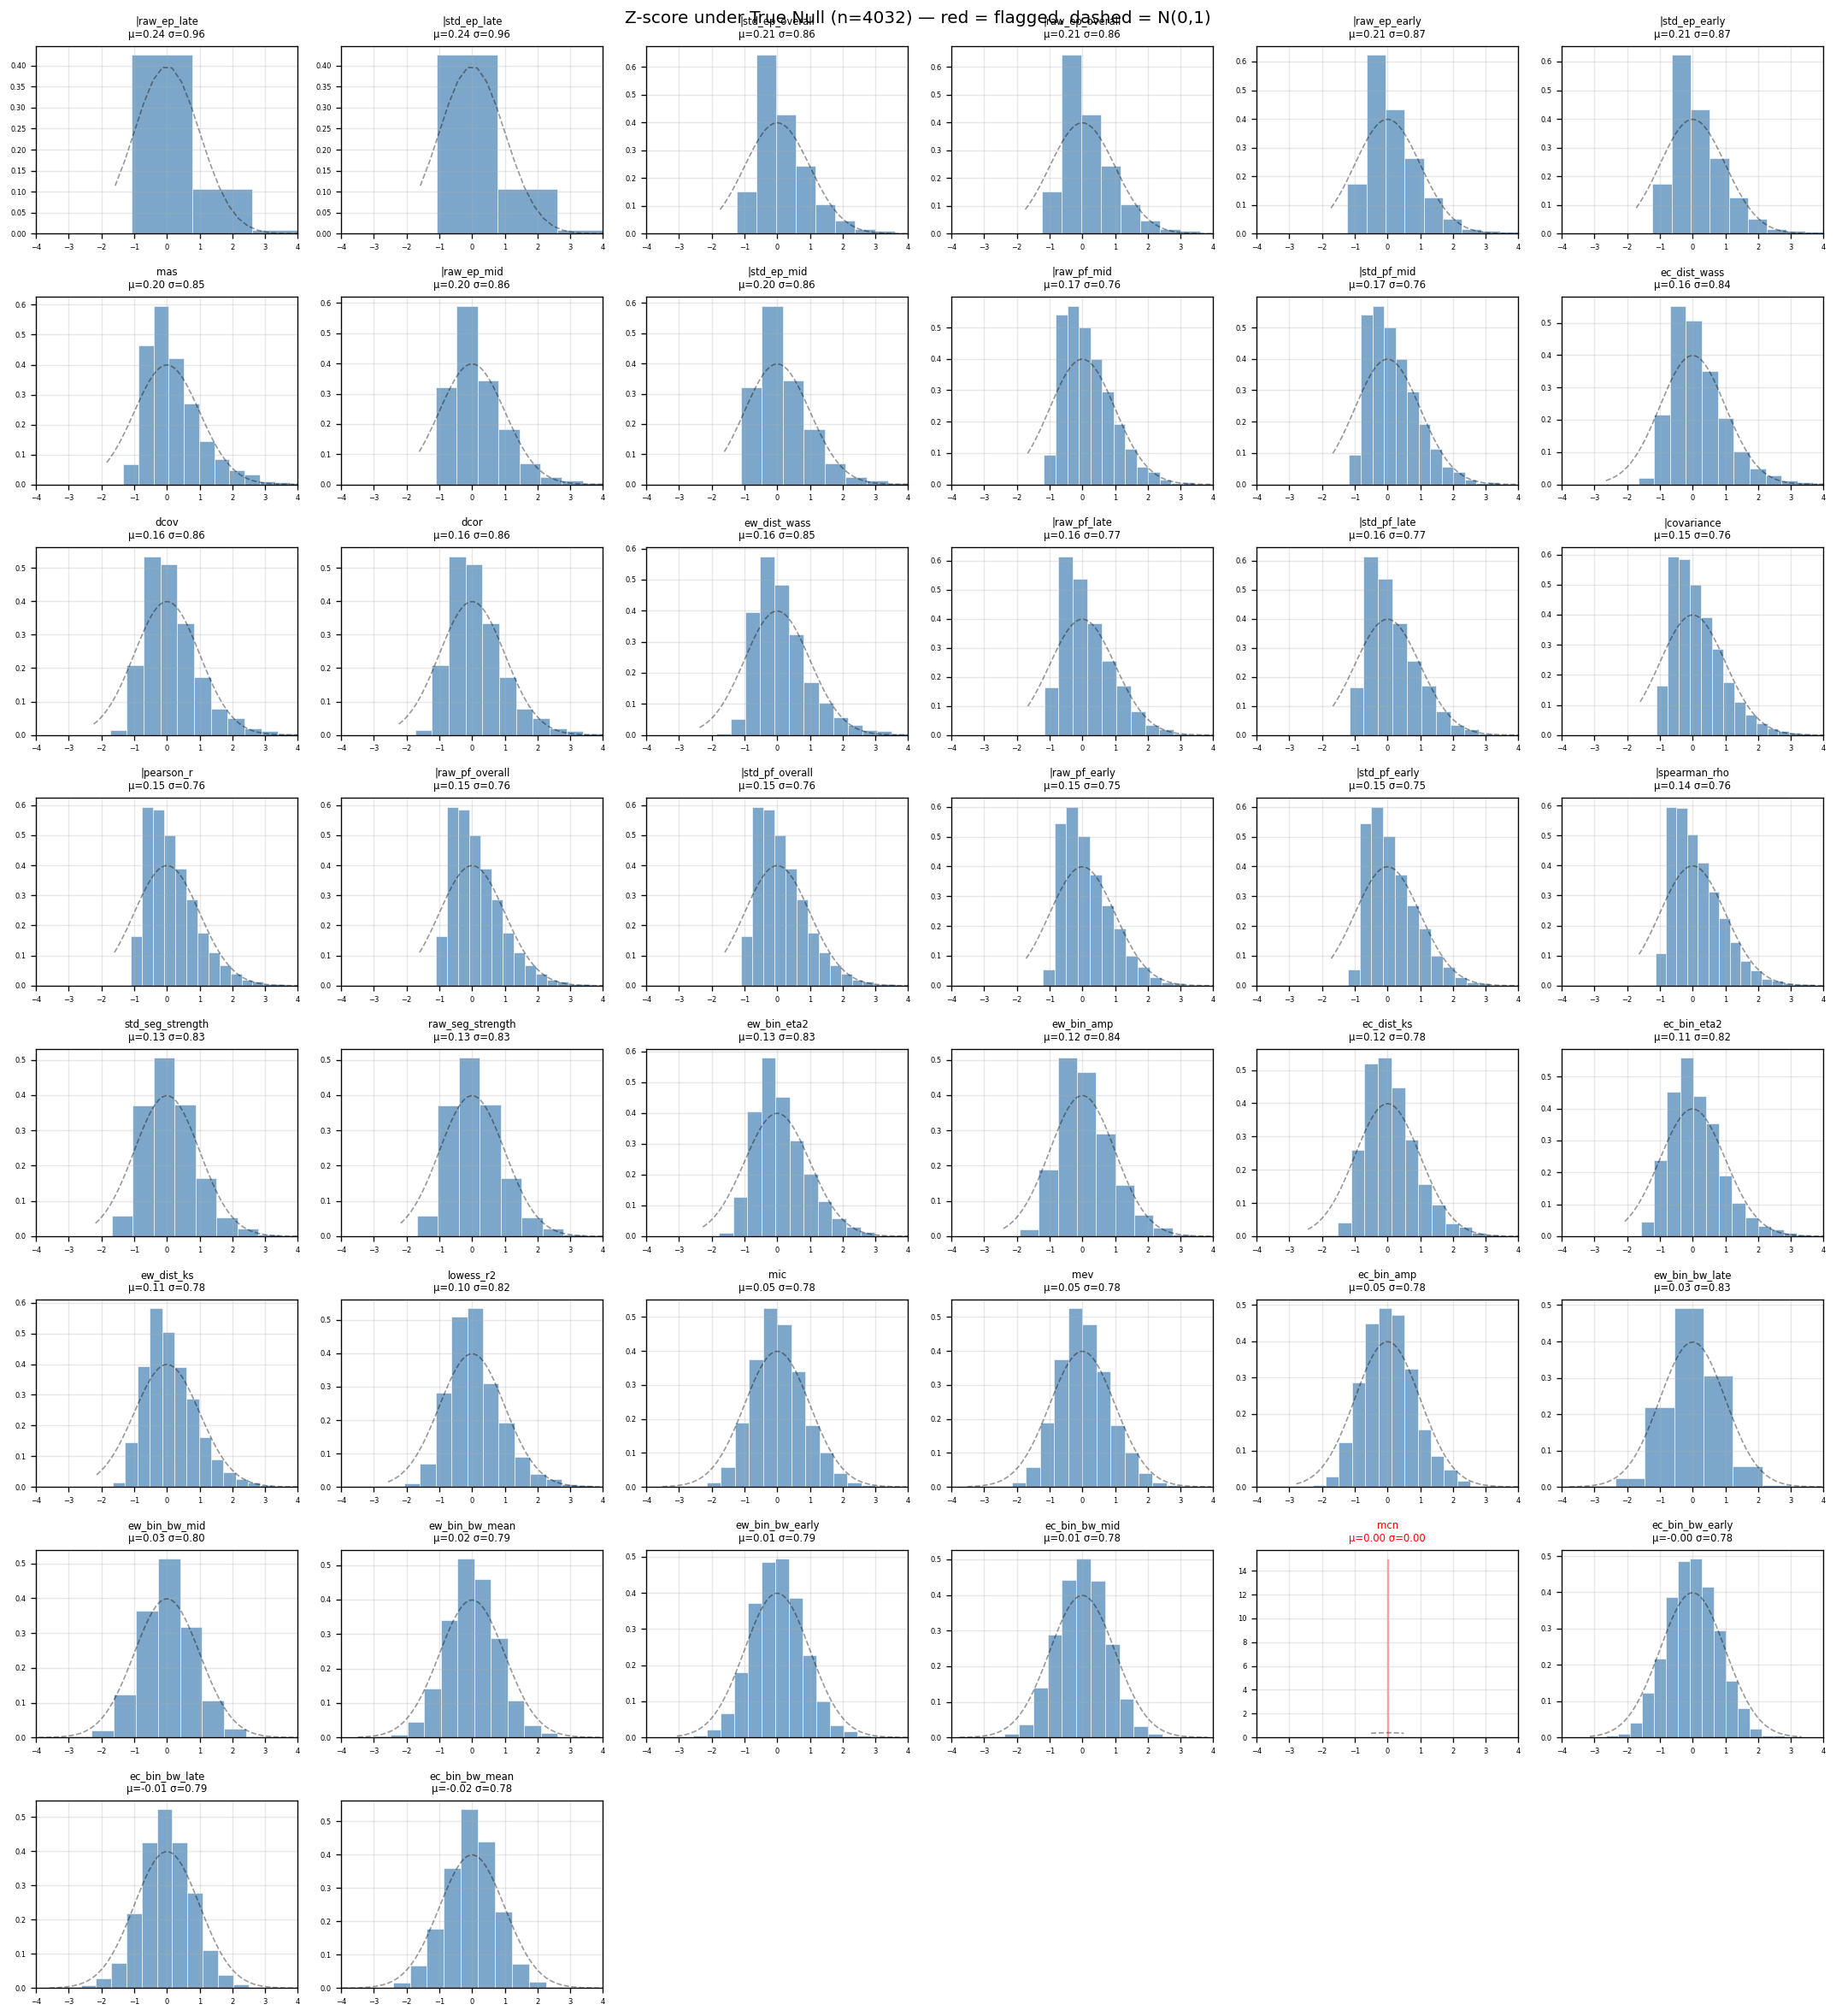

In [41]:
# ── 2.5c  Z-score histograms under null (all 39 metrics) ──
n_metrics = len(Z_COLS)
n_cols_plot = 6
n_rows_plot = (n_metrics + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(3 * n_cols_plot, 2.5 * n_rows_plot))
axes_flat = axes.flatten()

from scipy import stats as sp_stats

for idx, zc in enumerate(calib.sort_values('mean', ascending=False)['metric']):
    ax = axes_flat[idx]
    z_null = df.loc[null_mask, zc].dropna()
    row = calib[calib['metric'] == zc].iloc[0]

    ax.hist(z_null, bins=15, density=True, alpha=0.7,
            color='salmon' if row['flagged'] else 'steelblue',
            edgecolor='white', linewidth=0.5)

    # Overlay N(0,1) reference
    xx = np.linspace(z_null.min() - 0.5, z_null.max() + 0.5, 100)
    ax.plot(xx, sp_stats.norm.pdf(xx), 'k--', alpha=0.4, lw=1)

    ax.set_title(f'{METRIC_DISPLAY[zc]}\nμ={row["mean"]:.2f} σ={row["std"]:.2f}',
                 fontsize=7, color='red' if row['flagged'] else 'black')
    ax.tick_params(labelsize=5)
    ax.set_xlim(-4, 4)

for idx in range(n_metrics, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(f'Z-score under True Null (n={n_null}) — red = flagged, dashed = N(0,1)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
# ── 2.5d  Joint test FPR check ──
# B_S3 already computed joint p-value; check FPR on true_null
joint_fpr = (df.loc[null_mask, 'p_value'] <= 0.05).mean()
print(f'Joint test (all {len(Z_COLS)} metrics) empirical FPR on true_null: {joint_fpr:.1%}')
print(f'  (target: 5%, acceptable range: 3-8%)')
print(f'  classification breakdown on true_null:')
print(df.loc[null_mask, 'classification'].value_counts().to_string())
print()

# Also check: how does FPR change with number of metrics in the max-Z combo?
# More metrics → higher max-Z under null → FPR inflation if threshold not recalibrated
print('FPR by metric group (individual p ≤ 0.05 on true_null):')
for g in sorted(set(METRIC_GROUPS.values())):
    members = [c for c in Z_COLS if METRIC_GROUPS[c] == g]
    p_members = [c.replace('z_', 'p_') for c in members if c.replace('z_', 'p_') in df.columns]
    if p_members:
        fpr_any = (df.loc[null_mask, p_members].le(0.05).any(axis=1)).mean()
        fpr_individual = np.mean([
            (df.loc[null_mask, pc] <= 0.05).mean() for pc in p_members
        ])
        print(f'  {g:15s}  {len(p_members):2d} metrics  '
              f'avg individual FPR={fpr_individual:.1%}  '
              f'any-detected FPR={fpr_any:.1%}')

Joint test (all 44 metrics) empirical FPR on true_null: 4.7%
  (target: 5%, acceptable range: 3-8%)
  classification breakdown on true_null:
classification
not_detectable    3655
detectable         189
uncertain          188

FPR by metric group (individual p ≤ 0.05 on true_null):
  bin              12 metrics  avg individual FPR=5.0%  any-detected FPR=37.1%
  correlation       3 metrics  avg individual FPR=4.8%  any-detected FPR=6.4%
  distance          2 metrics  avg individual FPR=4.8%  any-detected FPR=4.8%
  distribution      4 metrics  avg individual FPR=4.6%  any-detected FPR=10.4%
  mine              4 metrics  avg individual FPR=3.5%  any-detected FPR=7.7%
  nonlinear         1 metrics  avg individual FPR=4.6%  any-detected FPR=4.6%
  slope            18 metrics  avg individual FPR=4.8%  any-detected FPR=31.8%


## 3. Individual Metric Performance

For each metric, compute **overall power** (detection rate on all signal cases combined) and per-category breakdown as diagnostics. Threshold calibrated to FPR=5% on true_null.

In [43]:
null_mask = df['category'] == 'true_null'
signal_mask = ~null_mask
n_signal = signal_mask.sum()
ALPHA = 0.05

results = []
for zc in Z_COLS:
    z_vals = df[zc].values
    z_null = z_vals[null_mask]
    
    threshold = float(np.nanpercentile(z_null, 100 * (1 - ALPHA)))
    detected = z_vals > threshold
    
    row = {'metric': zc, 'group': METRIC_GROUPS[zc], 'threshold': threshold}
    
    # Overall power: all signal cases combined
    sig_valid = df.loc[signal_mask, zc].notna()
    row['overall_power'] = float(detected[signal_mask][sig_valid].mean()) if sig_valid.sum() > 0 else np.nan
    
    for cat in ['true_null', 'mean_only', 'variance_only', 'mean+variance']:
        mask = df['category'] == cat
        n_cat = mask.sum()
        n_det = (detected & mask).sum()
        row[f'rate_{cat}'] = n_det / n_cat if n_cat > 0 else np.nan
        row[f'n_{cat}'] = n_cat
    results.append(row)

res_df = pd.DataFrame(results)
res_df = res_df.sort_values('overall_power', ascending=False)

print(f'Individual metric performance (threshold calibrated at FPR={ALPHA}):')
print(f'Signal cases: {n_signal:,} (MO={5000} + VO={2976} + MV={5000})')
print()
print(f'{"metric":>25s}  {"group":>12s}  {"POWER":>7s}  {"FPR":>5s}  │ {"MO":>5s}  {"VO":>5s}  {"MV":>5s}')
print('─' * 85)
for _, r in res_df.iterrows():
    print(f'{METRIC_DISPLAY[r["metric"]]:>25s}  {r["group"]:>12s}  '
          f'{r["overall_power"]:.1%}  {r["rate_true_null"]:.1%}  │ '
          f'{r["rate_mean_only"]:.1%}  {r["rate_variance_only"]:.1%}  {r["rate_mean+variance"]:.1%}')

Individual metric performance (threshold calibrated at FPR=0.05):
Signal cases: 12,976 (MO=5000 + VO=2976 + MV=5000)

                   metric         group    POWER    FPR  │    MO     VO     MV
─────────────────────────────────────────────────────────────────────────────────────
                     dcov      distance  98.1%  5.0%  │ 95.8%  98.7%  100.0%
                     dcor      distance  98.1%  5.0%  │ 95.8%  98.7%  100.0%
                      mic          mine  91.9%  5.0%  │ 17.8%  90.1%  20.0%
             ec_dist_wass  distribution  90.2%  5.0%  │ 91.7%  75.7%  97.3%
               ew_dist_ks  distribution  90.1%  5.0%  │ 90.6%  77.3%  97.2%
             ew_dist_wass  distribution  89.8%  5.0%  │ 91.5%  75.7%  96.6%
               ec_dist_ks  distribution  89.7%  5.0%  │ 90.3%  76.2%  97.2%
                      mev          mine  86.9%  5.0%  │ 17.8%  81.7%  20.0%
                      mas          mine  77.0%  5.0%  │ 9.0%  90.3%  13.9%
              ew_bin_eta2       

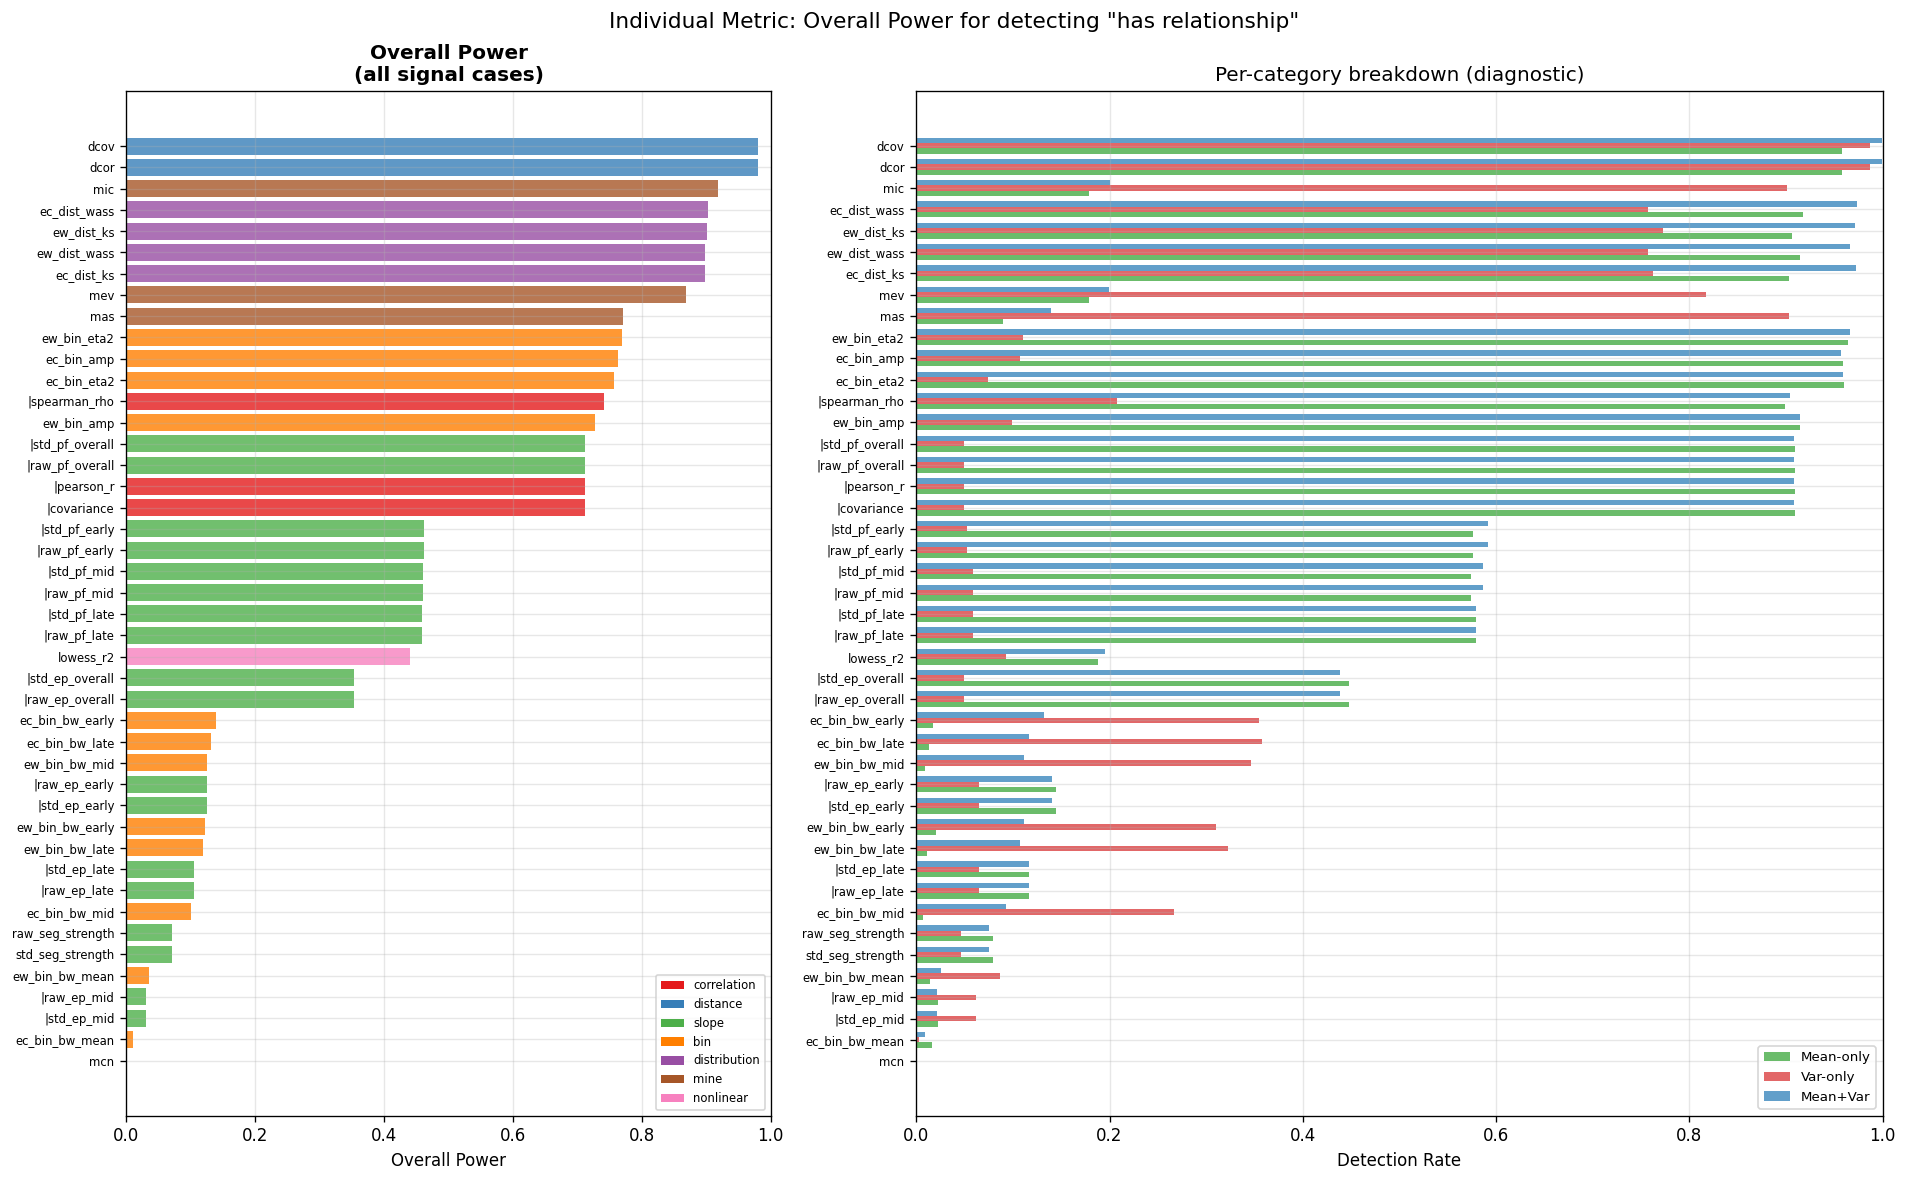

In [44]:
# Primary view: overall power (binary: no-relationship vs has-relationship)
fig, axes = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [2, 3]})

plot_df = res_df.sort_values('overall_power', ascending=True)

# Left: Overall Power (the optimization target)
ax = axes[0]
colors = [GROUP_COLORS[METRIC_GROUPS[m]] for m in plot_df['metric']]
labels = [METRIC_DISPLAY[m] for m in plot_df['metric']]
ax.barh(range(len(plot_df)), plot_df['overall_power'].values, color=colors, alpha=0.8)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Overall Power')
ax.set_title('Overall Power\n(all signal cases)', fontweight='bold')
ax.set_xlim(0, 1)

# Right: per-category breakdown (diagnostic)
ax = axes[1]
y = np.arange(len(plot_df))
h = 0.25
ax.barh(y - h, plot_df['rate_mean_only'].values, h, label='Mean-only', color='#2ca02c', alpha=0.7)
ax.barh(y,     plot_df['rate_variance_only'].values, h, label='Var-only', color='#d62728', alpha=0.7)
ax.barh(y + h, plot_df['rate_mean+variance'].values, h, label='Mean+Var', color='#1f77b4', alpha=0.7)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Detection Rate')
ax.set_title('Per-category breakdown (diagnostic)')
ax.set_xlim(0, 1)
ax.legend(fontsize=8, loc='lower right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()
                   if g in set(METRIC_GROUPS.values())]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=7)
fig.suptitle('Individual Metric: Overall Power for detecting "has relationship"', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Metric Redundancy (Z-score Correlation)

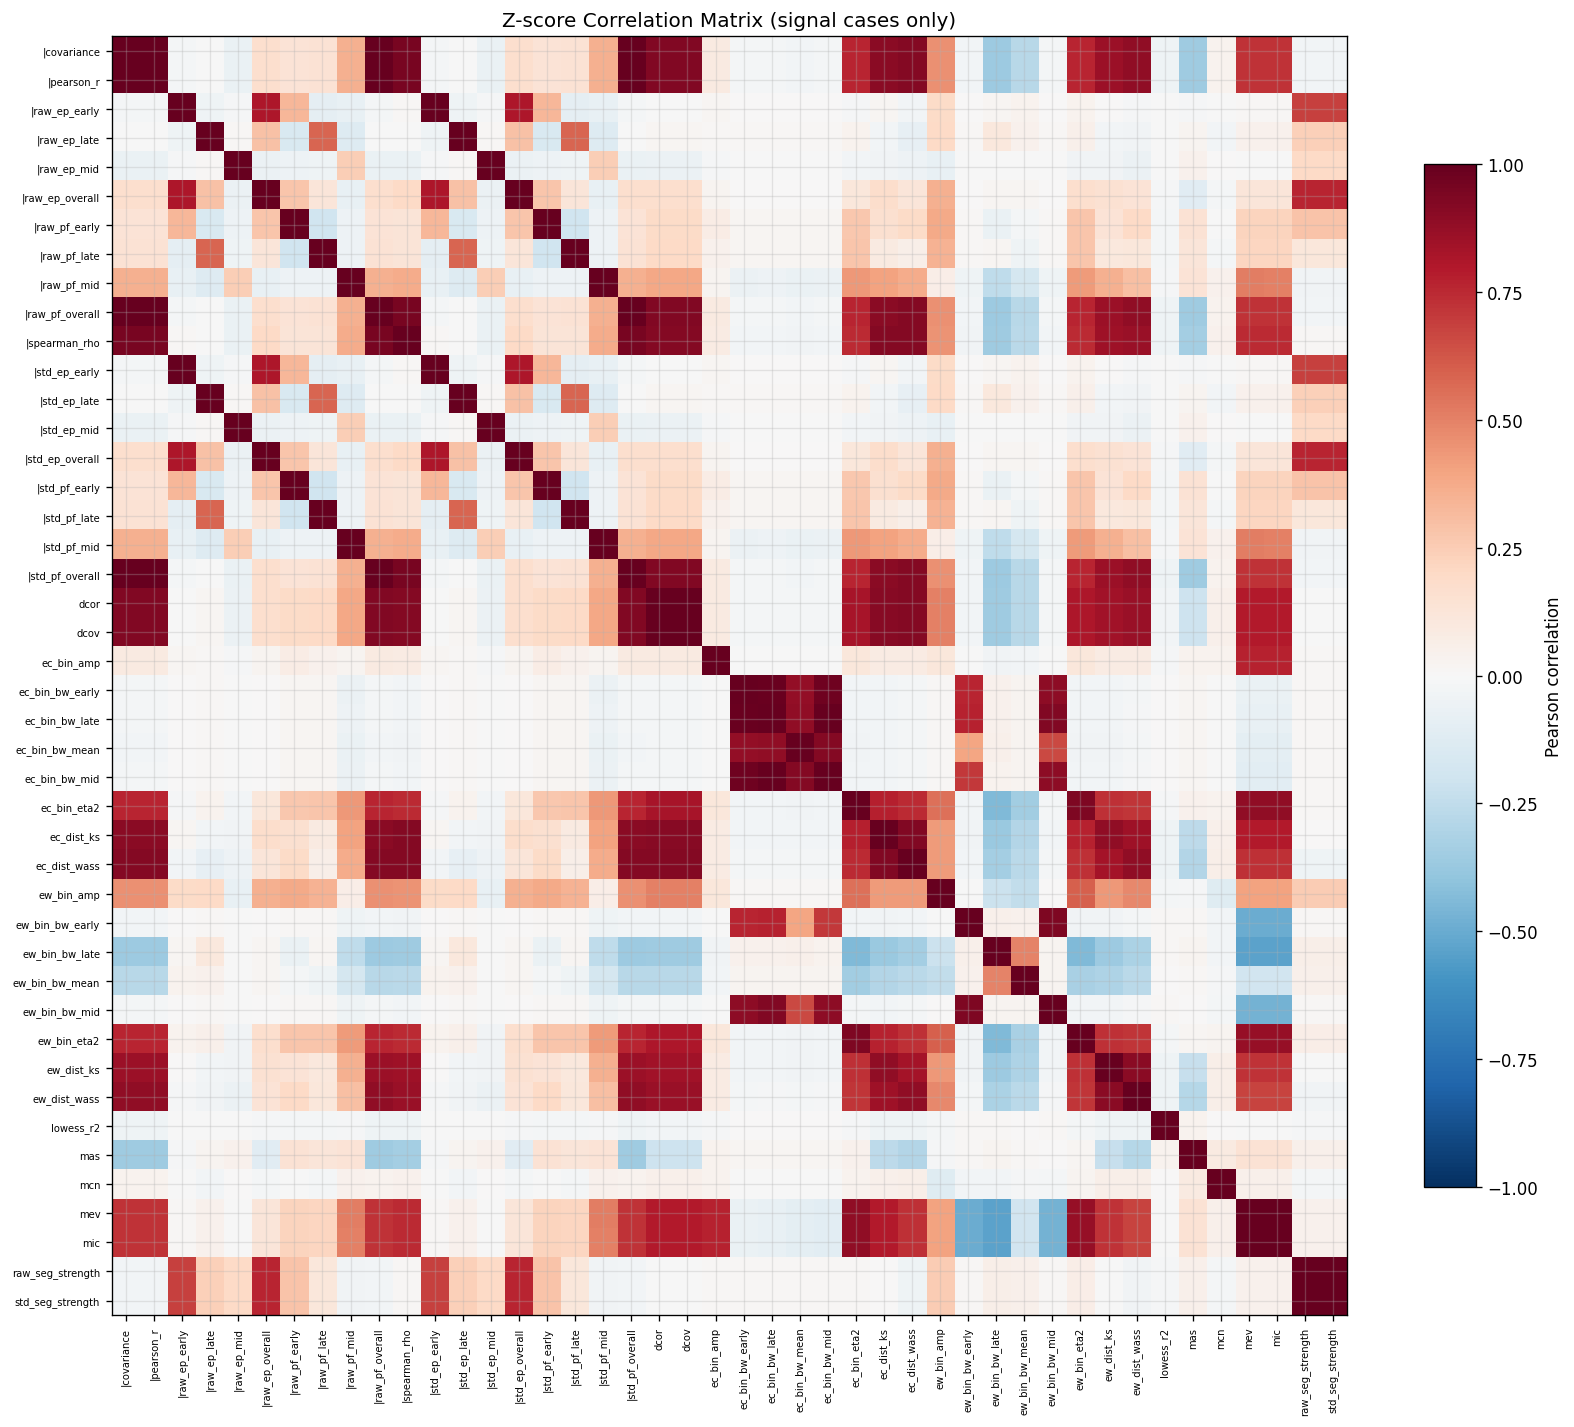


Highly correlated pairs (|r| > 0.9):
  |covariance                    — |pearson_r                      r=1.000
  |covariance                    — |raw_pf_overall                 r=1.000
  |covariance                    — |spearman_rho                   r=0.952
  |covariance                    — |std_pf_overall                 r=1.000
  |covariance                    — dcor                            r=0.922
  |covariance                    — dcov                            r=0.922
  |covariance                    — ec_dist_ks                      r=0.902
  |covariance                    — ec_dist_wass                    r=0.920
  |pearson_r                     — |raw_pf_overall                 r=1.000
  |pearson_r                     — |spearman_rho                   r=0.952
  |pearson_r                     — |std_pf_overall                 r=1.000
  |pearson_r                     — dcor                            r=0.922
  |pearson_r                     — dcov                       

In [45]:
# Correlation of Z-scores across signal cases
signal_mask = df['category'].isin(['mean_only', 'mean+variance'])
z_signal = df.loc[signal_mask, Z_COLS]

corr = z_signal.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
labels = [METRIC_DISPLAY[c] for c in Z_COLS]
ax.set_xticks(range(len(Z_COLS)))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_yticks(range(len(Z_COLS)))
ax.set_yticklabels(labels, fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')
ax.set_title('Z-score Correlation Matrix (signal cases only)')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print('\nHighly correlated pairs (|r| > 0.9):')
for i in range(len(Z_COLS)):
    for j in range(i+1, len(Z_COLS)):
        r = corr.iloc[i, j]
        if abs(r) > 0.9:
            print(f'  {METRIC_DISPLAY[Z_COLS[i]]:30s} — {METRIC_DISPLAY[Z_COLS[j]]:30s}  r={r:.3f}')

## 5. Function × SNR Detection Heatmap (Mean-only)

For each candidate metric, show a heatmap: rows = function family, columns = SNR, cell = detection rate.

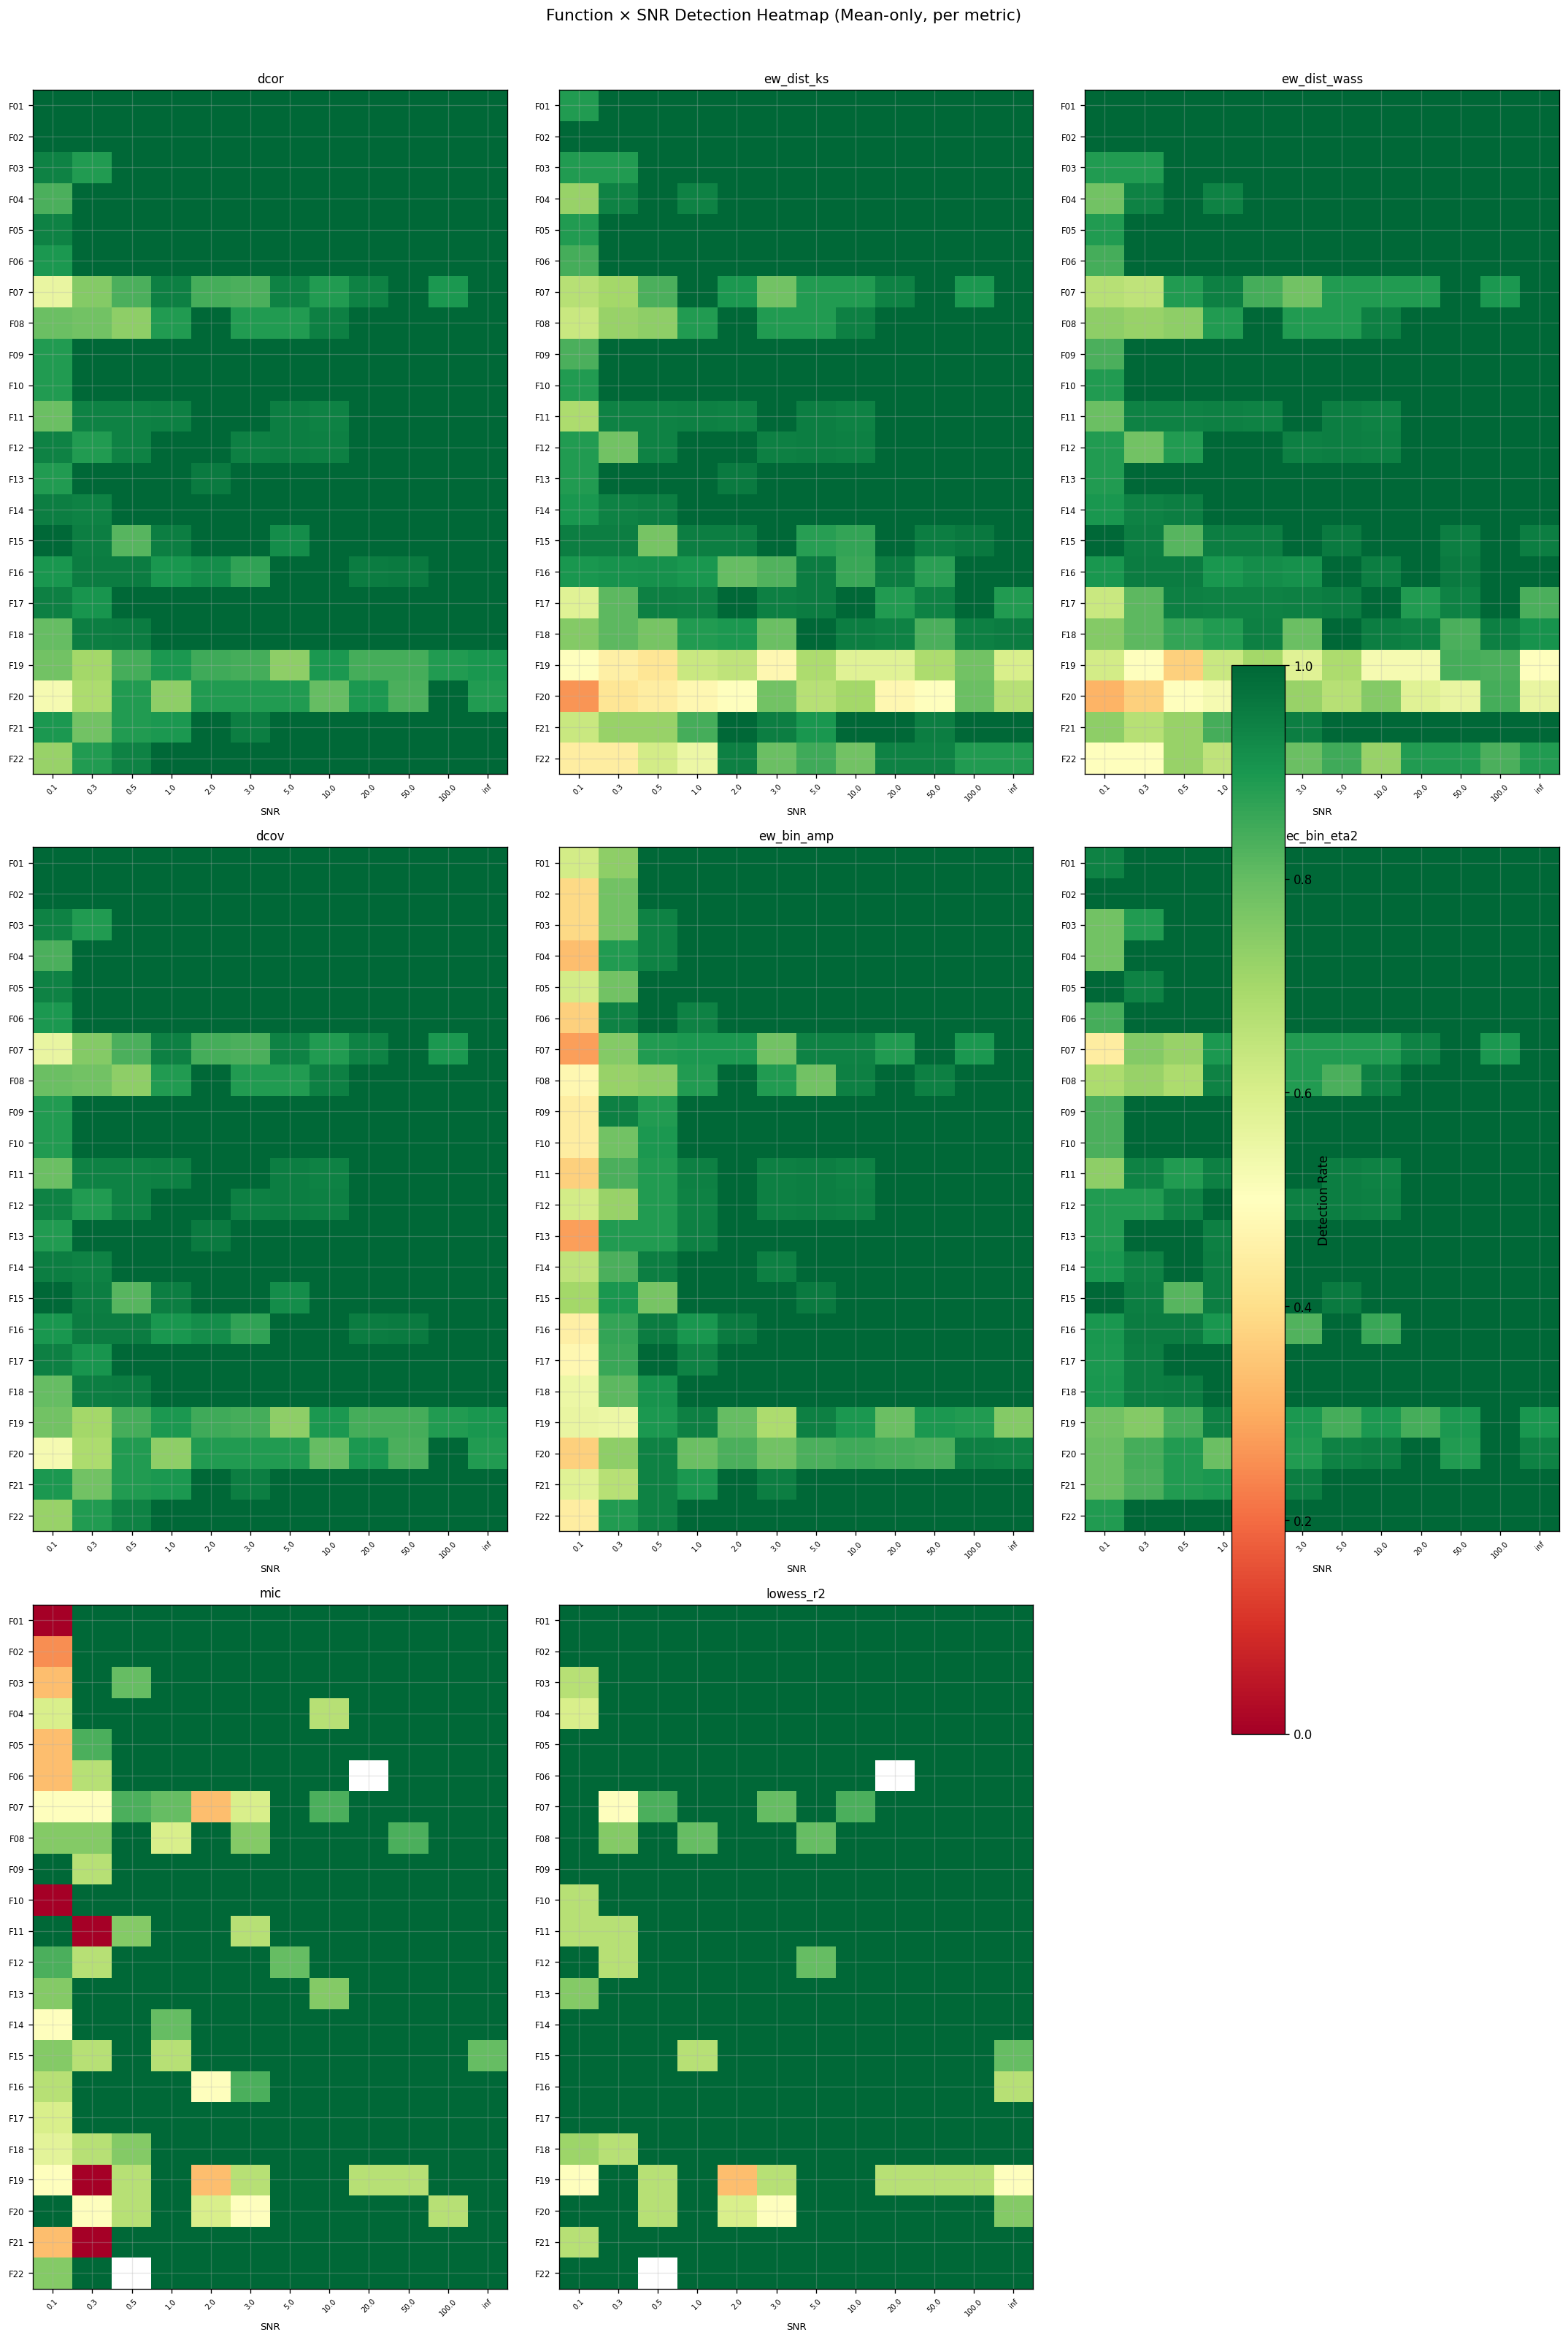

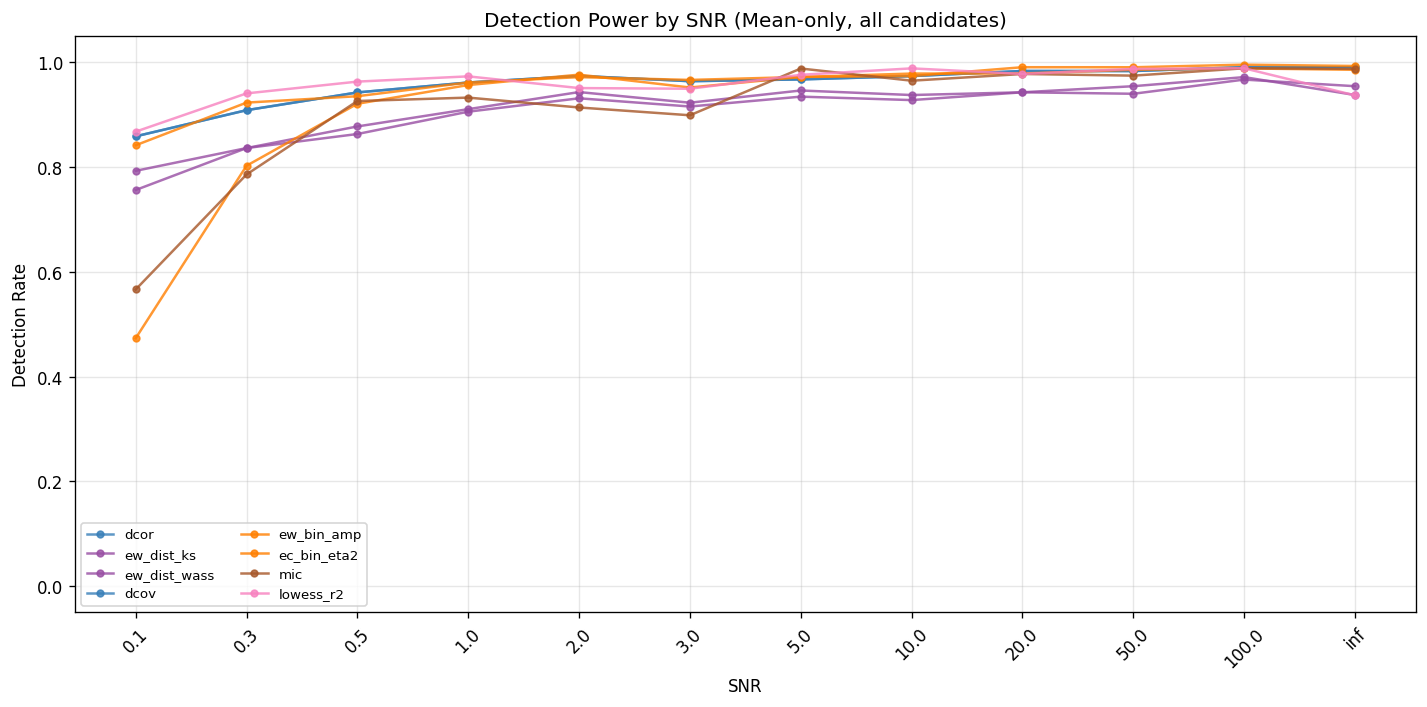

In [46]:
CANDIDATES = ['z_pearson', 'z_spearman', 'z_dcor', 'z_eta2',
              'z_ew_dist_ks', 'z_ew_dist_wass', 'z_dcov',
              'z_ew_bin_amp', 'z_ec_bin_eta2',
              'z_mic', 'z_lowess_r2']
CANDIDATES = [c for c in CANDIDATES if c in Z_COLS]

thresholds = {}
for zc in CANDIDATES:
    thresholds[zc] = float(np.nanpercentile(df.loc[null_mask, zc].dropna(), 95))

mean_only = df[df['category'] == 'mean_only'].copy()
families = sorted(mean_only['family_id'].unique())
snr_levels = sorted(mean_only['snr'].unique())

n_cands = len(CANDIDATES)
n_cols = min(3, n_cands)
n_rows = (n_cands + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 0.4 * len(families) * n_rows))
if n_cands == 1:
    axes = np.array([[axes]])
axes = np.atleast_2d(axes)

for idx, zc in enumerate(CANDIDATES):
    ax = axes.flatten()[idx]
    heatmap = np.zeros((len(families), len(snr_levels)))
    for i, fam in enumerate(families):
        for j, snr in enumerate(snr_levels):
            sub = mean_only[(mean_only['family_id'] == fam) & (mean_only['snr'] == snr)]
            valid = sub[zc].dropna()
            if len(valid) > 0:
                heatmap[i, j] = (valid > thresholds[zc]).mean()
            else:
                heatmap[i, j] = np.nan

    im = ax.imshow(heatmap, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(snr_levels)))
    ax.set_xticklabels([str(s) for s in snr_levels], fontsize=6, rotation=45)
    ax.set_yticks(range(len(families)))
    ax.set_yticklabels(families, fontsize=7)
    ax.set_title(METRIC_DISPLAY[zc], fontsize=10)
    ax.set_xlabel('SNR', fontsize=8)

# Hide empty subplots
for idx in range(n_cands, len(axes.flatten())):
    axes.flatten()[idx].set_visible(False)

fig.colorbar(im, ax=axes, shrink=0.6, label='Detection Rate')
fig.suptitle('Function × SNR Detection Heatmap (Mean-only, per metric)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# SNR curve comparison
fig, ax = plt.subplots(figsize=(12, 6))
for zc in CANDIDATES:
    rates = []
    for snr in snr_levels:
        subset = mean_only[mean_only['snr'] == snr]
        valid = subset[zc].dropna()
        rates.append((valid > thresholds[zc]).mean() if len(valid) > 0 else np.nan)
    color = GROUP_COLORS[METRIC_GROUPS[zc]]
    ax.plot(range(len(snr_levels)), rates, 'o-', label=METRIC_DISPLAY[zc],
            color=color, alpha=0.8, markersize=4)

ax.set_xticks(range(len(snr_levels)))
ax.set_xticklabels([str(s) for s in snr_levels], rotation=45)
ax.set_xlabel('SNR')
ax.set_ylabel('Detection Rate')
ax.set_title('Detection Power by SNR (Mean-only, all candidates)')
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 6. Variance-only Detection

Variance-only: 2976 cases, True null: 4032 cases



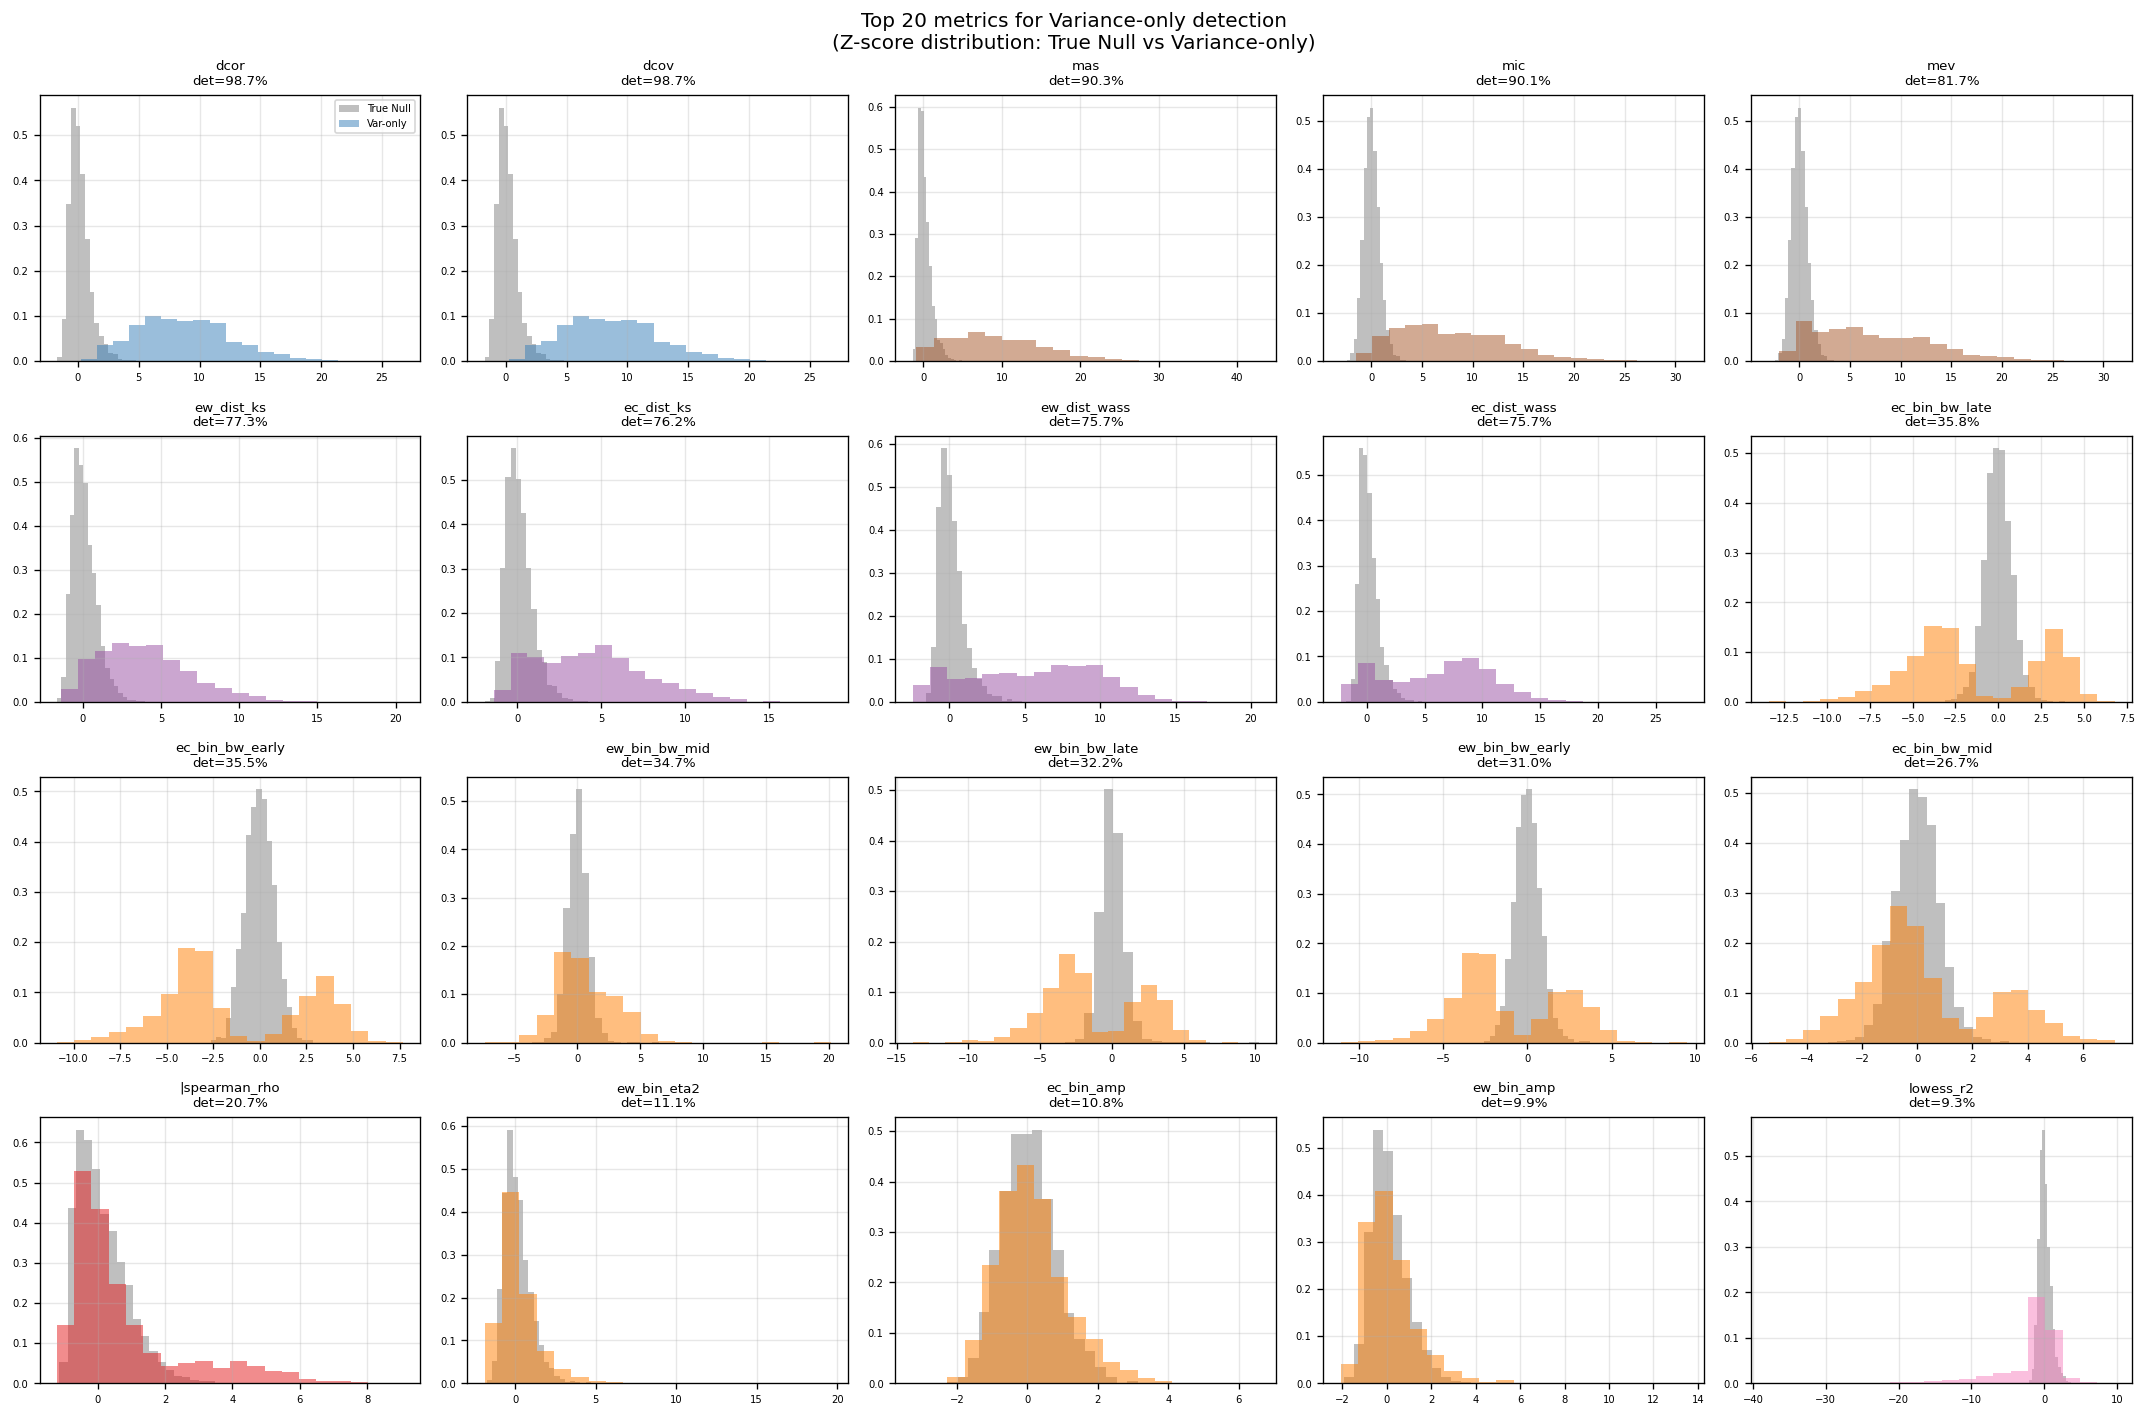


Variance-only detection rates (top 15):
  dcor                                 98.7%  (distance)
  dcov                                 98.7%  (distance)
  mas                                  90.3%  (mine)
  mic                                  90.1%  (mine)
  mev                                  81.7%  (mine)
  ew_dist_ks                           77.3%  (distribution)
  ec_dist_ks                           76.2%  (distribution)
  ew_dist_wass                         75.7%  (distribution)
  ec_dist_wass                         75.7%  (distribution)
  ec_bin_bw_late                       35.8%  (bin)
  ec_bin_bw_early                      35.5%  (bin)
  ew_bin_bw_mid                        34.7%  (bin)
  ew_bin_bw_late                       32.2%  (bin)
  ew_bin_bw_early                      31.0%  (bin)
  ec_bin_bw_mid                        26.7%  (bin)


In [47]:
vo = df[df['category'] == 'variance_only'].copy()
tn = df[df['category'] == 'true_null'].copy()

print(f'Variance-only: {len(vo)} cases, True null: {len(tn)} cases')
print()

# For each metric, show Z-score distribution for variance_only vs true_null
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes_flat = axes.flatten()

# Show top 20 metrics by variance-only detection
vo_rates = []
for zc in Z_COLS:
    thr = float(np.nanpercentile(tn[zc], 95))
    rate = (vo[zc] > thr).mean()
    vo_rates.append((zc, rate))
vo_rates.sort(key=lambda x: -x[1])

for idx, (zc, rate) in enumerate(vo_rates[:20]):
    ax = axes_flat[idx]
    ax.hist(tn[zc].dropna(), bins=20, alpha=0.5, density=True, color='gray', label='True Null')
    ax.hist(vo[zc].dropna(), bins=20, alpha=0.5, density=True,
            color=GROUP_COLORS[METRIC_GROUPS[zc]], label='Var-only')
    ax.set_title(f'{METRIC_DISPLAY[zc]}\ndet={rate:.1%}', fontsize=8)
    ax.tick_params(labelsize=6)
    if idx == 0:
        ax.legend(fontsize=6)

fig.suptitle('Top 20 metrics for Variance-only detection\n(Z-score distribution: True Null vs Variance-only)', fontsize=12)
plt.tight_layout()
plt.show()

print('\nVariance-only detection rates (top 15):')
for zc, rate in vo_rates[:15]:
    print(f'  {METRIC_DISPLAY[zc]:35s}  {rate:.1%}  ({METRIC_GROUPS[zc]})')

## 6.5. Mean+Variance Detection Analysis

Mean+Variance cases have both f(x) varying and σ(x) varying. At low SNR, the mean signal
may be too weak for correlation metrics — does the variance component help?

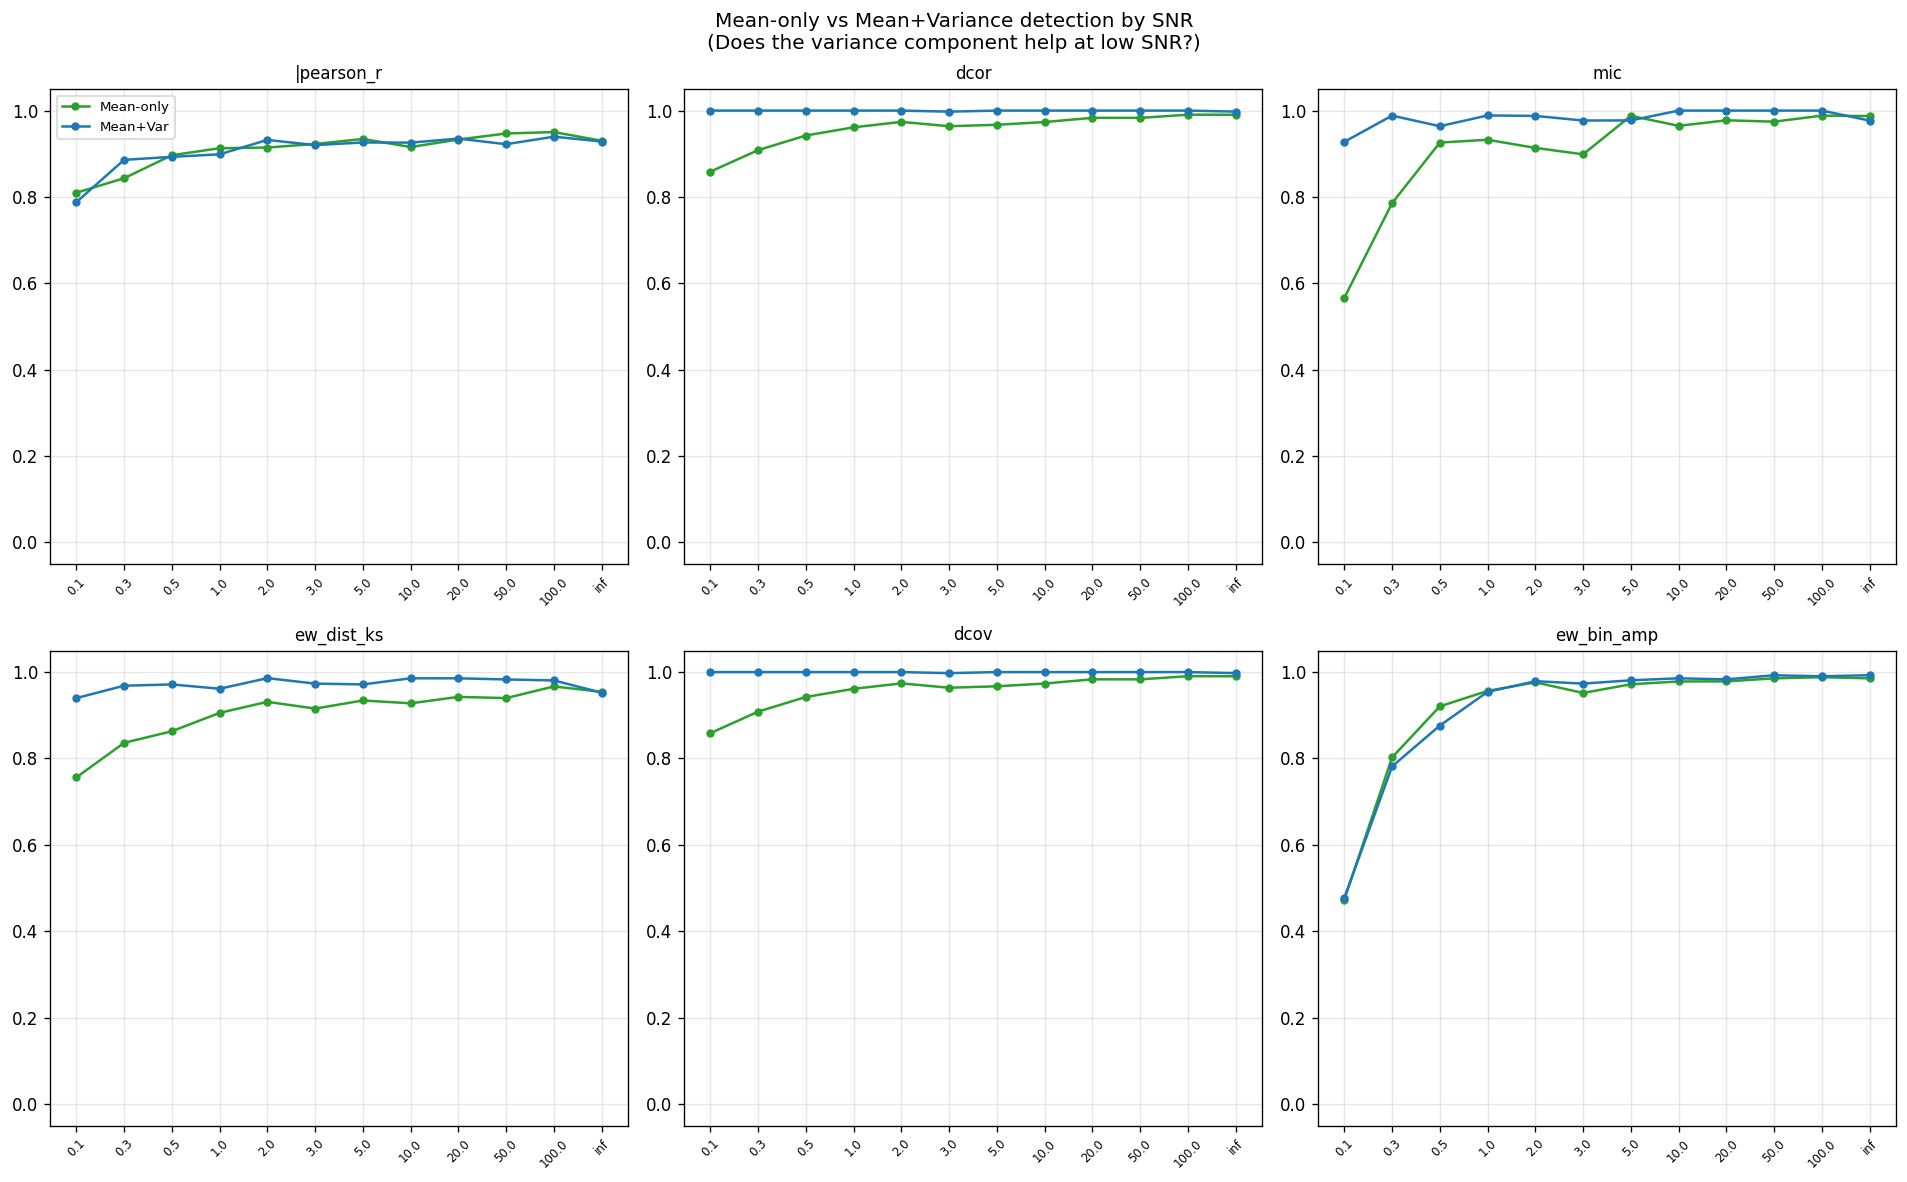


Mean+Variance at low SNR (0.1, 0.3): 827 cases

Per-metric detection rates:
  dcor                            100.0%  (n=827)
  ew_dist_ks                      95.4%  (n=827)
  ew_dist_wass                    95.6%  (n=827)
  dcov                            100.0%  (n=827)
  ew_bin_amp                      62.9%  (n=827)
  ec_bin_eta2                     85.9%  (n=827)
  mic                             95.9%  (n=169)
  lowess_r2                       86.4%  (n=169)


In [48]:
mv = df[df['category'] == 'mean+variance'].copy()
mo = df[df['category'] == 'mean_only'].copy()

# Compare detection rates: mean_only vs mean+variance at each SNR
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_metrics = ['z_abs_pearson_r', 'z_dcor', 'z_mic',
                'z_ew_dist_ks', 'z_dcov', 'z_ew_bin_amp']
plot_metrics = [m for m in plot_metrics if m in Z_COLS]

for idx, zc in enumerate(plot_metrics):
    ax = axes.flatten()[idx]
    thr = float(np.nanpercentile(df.loc[null_mask, zc].dropna(), 95))

    for sub_df, label, color in [(mo, 'Mean-only', '#2ca02c'),
                                  (mv, 'Mean+Var', '#1f77b4')]:
        rates = []
        for snr in snr_levels:
            s = sub_df[sub_df['snr'] == snr]
            valid = s[zc].dropna()
            rates.append((valid > thr).mean() if len(valid) > 0 else np.nan)
        ax.plot(range(len(snr_levels)), rates, 'o-', label=label,
                color=color, markersize=4)

    ax.set_xticks(range(len(snr_levels)))
    ax.set_xticklabels([str(s) for s in snr_levels], fontsize=7, rotation=45)
    ax.set_title(METRIC_DISPLAY[zc], fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    if idx == 0:
        ax.legend(fontsize=8)

for idx in range(len(plot_metrics), len(axes.flatten())):
    axes.flatten()[idx].set_visible(False)

fig.suptitle('Mean-only vs Mean+Variance detection by SNR\n'
             '(Does the variance component help at low SNR?)', fontsize=12)
plt.tight_layout()
plt.show()

# At low SNR, which metric drives detection for mean+variance?
low_snr_mv = mv[mv['snr'].isin([0.1, 0.3])].copy()
print(f'\nMean+Variance at low SNR (0.1, 0.3): {len(low_snr_mv)} cases')
print('\nPer-metric detection rates:')
for zc in CANDIDATES:
    thr = thresholds[zc]
    valid = low_snr_mv[zc].dropna()
    rate = (valid > thr).mean() if len(valid) > 0 else np.nan
    print(f'  {METRIC_DISPLAY[zc]:30s}  {rate:.1%}  (n={len(valid)})')

## 7. Metric Combination Search

For each combination size (1 to 6), find the best subset that maximizes
**overall power** (detection rate on all signal cases combined: MO + VO + MV)
while keeping FPR ≤ 5% on true_null.

T_combo = max(Z across selected metrics). Threshold set from true_null.

In [49]:
def evaluate_combo(z_df, category, metrics, alpha=0.05):
    """Evaluate a metric combination. Score = overall power on all signal cases."""
    null_z = z_df.loc[category == 'true_null', metrics]
    T_null = null_z.max(axis=1)
    threshold = float(np.nanpercentile(T_null, 100 * (1 - alpha)))
    
    T_all = z_df[metrics].max(axis=1)
    detected = T_all > threshold
    
    result = {'threshold': threshold, 'n_metrics': len(metrics)}
    
    # Per-category rates (diagnostic)
    for cat in ['true_null', 'mean_only', 'variance_only', 'mean+variance']:
        mask = category == cat
        result[f'rate_{cat}'] = float(detected[mask].mean()) if mask.sum() > 0 else np.nan
    
    # Overall power: all signal cases combined (THE optimization target)
    signal_mask = category != 'true_null'
    sig_detected = detected[signal_mask]
    sig_valid = z_df.loc[signal_mask, metrics].max(axis=1).notna()
    result['overall_power'] = float(sig_detected[sig_valid].mean()) if sig_valid.sum() > 0 else np.nan
    
    return result

# Pre-select top candidates — only from SAFE (calibrated) metrics
safe_res = res_df[res_df['metric'].isin(SAFE_METRICS)]

# Take top 3 from each group by overall_power
top_per_group = (safe_res.sort_values('overall_power', ascending=False)
                 .groupby('group').head(3)['metric'].tolist())

# Also add top variance_only detectors (safe only)
safe_vo_rates = [(zc, r) for zc, r in vo_rates if zc in SAFE_METRICS]
top_vo = [zc for zc, _ in safe_vo_rates[:5]]
search_pool = list(set(top_per_group + top_vo))

print(f'Search pool (safe metrics only): {len(search_pool)} metrics')
for m in sorted(search_pool):
    print(f'  {METRIC_DISPLAY[m]} ({METRIC_GROUPS[m]})')

Search pool (safe metrics only): 18 metrics
  |covariance (correlation)
  |pearson_r (correlation)
  |raw_pf_overall (slope)
  |spearman_rho (correlation)
  |std_pf_early (slope)
  |std_pf_overall (slope)
  dcor (distance)
  dcov (distance)
  ec_bin_amp (bin)
  ec_bin_eta2 (bin)
  ec_dist_wass (distribution)
  ew_bin_eta2 (bin)
  ew_dist_ks (distribution)
  ew_dist_wass (distribution)
  lowess_r2 (nonlinear)
  mas (mine)
  mev (mine)
  mic (mine)


In [50]:
z_df_search = df[search_pool]
category = df['category']

best_per_size = {}

for k in range(1, min(7, len(search_pool) + 1)):
    best_power = -1
    best_combo = None
    best_result = None
    
    combos = list(combinations(search_pool, k))
    print(f'Size {k}: testing {len(combos):,} combinations...')
    
    for combo in combos:
        result = evaluate_combo(df, category, list(combo))
        if result['overall_power'] > best_power:
            best_power = result['overall_power']
            best_combo = combo
            best_result = result
    
    best_result['metrics'] = best_combo
    best_per_size[k] = best_result
    
    names = [METRIC_DISPLAY[m] for m in best_combo]
    print(f'  Best: {names}')
    print(f'  Overall Power={best_result["overall_power"]:.1%}  FPR={best_result["rate_true_null"]:.1%}  '
          f'│ MO={best_result["rate_mean_only"]:.1%}  '
          f'VO={best_result["rate_variance_only"]:.1%}  '
          f'MV={best_result["rate_mean+variance"]:.1%}')
    print()

Size 1: testing 18 combinations...
  Best: ['dcov']
  Overall Power=98.1%  FPR=5.0%  │ MO=95.8%  VO=98.7%  MV=100.0%

Size 2: testing 153 combinations...
  Best: ['dcov', 'ew_bin_eta2']
  Overall Power=98.3%  FPR=5.0%  │ MO=96.8%  VO=97.9%  MV=100.0%

Size 3: testing 816 combinations...
  Best: ['dcov', 'ew_bin_eta2', 'ec_bin_amp']
  Overall Power=98.3%  FPR=5.0%  │ MO=97.0%  VO=97.8%  MV=100.0%

Size 4: testing 3,060 combinations...
  Best: ['dcov', 'ew_bin_eta2', '|std_pf_early', 'ec_bin_amp']
  Overall Power=98.4%  FPR=5.0%  │ MO=97.2%  VO=97.5%  MV=100.0%

Size 5: testing 8,568 combinations...
  Best: ['dcov', 'ew_bin_eta2', 'mic', '|std_pf_early', 'ec_bin_amp']
  Overall Power=98.4%  FPR=5.0%  │ MO=97.2%  VO=97.8%  MV=99.9%

Size 6: testing 18,564 combinations...
  Best: ['dcov', '|spearman_rho', 'ew_bin_eta2', 'mic', '|std_pf_early', 'ec_bin_amp']
  Overall Power=98.4%  FPR=5.0%  │ MO=97.2%  VO=97.8%  MV=99.9%



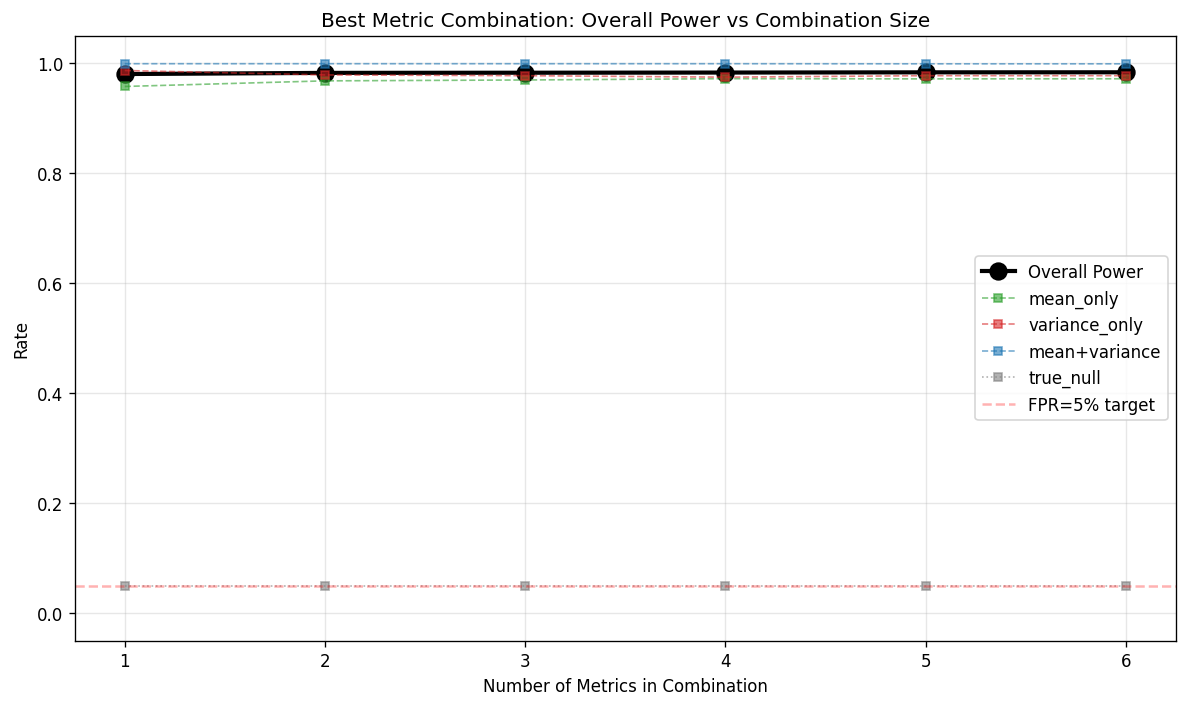


=== Summary: Overall Power (no-relationship vs has-relationship) ===

1 metric(s): [dcov]
  Overall Power: 98.1%   FPR: 5.0%
  (diagnostic: MO=95.8%  VO=98.7%  MV=100.0%)

2 metric(s): [dcov, ew_bin_eta2]
  Overall Power: 98.3%   FPR: 5.0%
  (diagnostic: MO=96.8%  VO=97.9%  MV=100.0%)

3 metric(s): [dcov, ew_bin_eta2, ec_bin_amp]
  Overall Power: 98.3%   FPR: 5.0%
  (diagnostic: MO=97.0%  VO=97.8%  MV=100.0%)

4 metric(s): [dcov, ew_bin_eta2, |std_pf_early, ec_bin_amp]
  Overall Power: 98.4%   FPR: 5.0%
  (diagnostic: MO=97.2%  VO=97.5%  MV=100.0%)

5 metric(s): [dcov, ew_bin_eta2, mic, |std_pf_early, ec_bin_amp]
  Overall Power: 98.4%   FPR: 5.0%
  (diagnostic: MO=97.2%  VO=97.8%  MV=99.9%)

6 metric(s): [dcov, |spearman_rho, ew_bin_eta2, mic, |std_pf_early, ec_bin_amp]
  Overall Power: 98.4%   FPR: 5.0%
  (diagnostic: MO=97.2%  VO=97.8%  MV=99.9%)


In [51]:
# Pareto plot: number of metrics vs overall power
fig, ax = plt.subplots(figsize=(10, 6))

sizes = sorted(best_per_size.keys())

# Primary: overall power (bold)
vals = [best_per_size[k]['overall_power'] for k in sizes]
ax.plot(sizes, vals, 'o-', label='Overall Power', color='black', markersize=10, lw=2.5)

# Diagnostic: per-category (thin)
for cat, color, ls in [('rate_mean_only', '#2ca02c', '--'),
                        ('rate_variance_only', '#d62728', '--'),
                        ('rate_mean+variance', '#1f77b4', '--'),
                        ('rate_true_null', '#7f7f7f', ':')]:
    vals = [best_per_size[k][cat] for k in sizes]
    label = cat.replace('rate_', '')
    ax.plot(sizes, vals, f's{ls}', label=label, color=color, markersize=5, lw=1, alpha=0.6)

ax.axhline(0.05, color='red', ls='--', alpha=0.3, label='FPR=5% target')
ax.set_xlabel('Number of Metrics in Combination')
ax.set_ylabel('Rate')
ax.set_title('Best Metric Combination: Overall Power vs Combination Size')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(sizes)
plt.tight_layout()
plt.show()

# Summary table
print('\n=== Summary: Overall Power (no-relationship vs has-relationship) ===')
for k in sizes:
    r = best_per_size[k]
    names = ', '.join(METRIC_DISPLAY[m] for m in r['metrics'])
    print(f'\n{k} metric(s): [{names}]')
    print(f'  Overall Power: {r["overall_power"]:.1%}   FPR: {r["rate_true_null"]:.1%}')
    print(f'  (diagnostic: MO={r["rate_mean_only"]:.1%}  VO={r["rate_variance_only"]:.1%}  MV={r["rate_mean+variance"]:.1%})')

## 7.5. Metric Ablation — Unique Contribution

Starting from the best 5-metric combo, remove each metric one at a time.
The drop in detection rate = that metric's **unique contribution**.


Ablation from best 3-metric combo: ['dcov', 'ew_bin_eta2', 'ec_bin_amp']
Baseline Overall Power: 98.3%  (MO=97.0%  VO=97.8%  MV=100.0%)
  Remove dcov                      → ΔPower=+20.7%  (ΔMO=+0.3%  ΔVO=+84.6%  ΔMV=+3.1%)  FPR=5.0%
  Remove ew_bin_eta2               → ΔPower=+0.1%  (ΔMO=+0.6%  ΔVO=-0.5%  ΔMV=+0.0%)  FPR=5.0%
  Remove ec_bin_amp                → ΔPower=+0.0%  (ΔMO=+0.2%  ΔVO=-0.1%  ΔMV=+0.0%)  FPR=5.0%


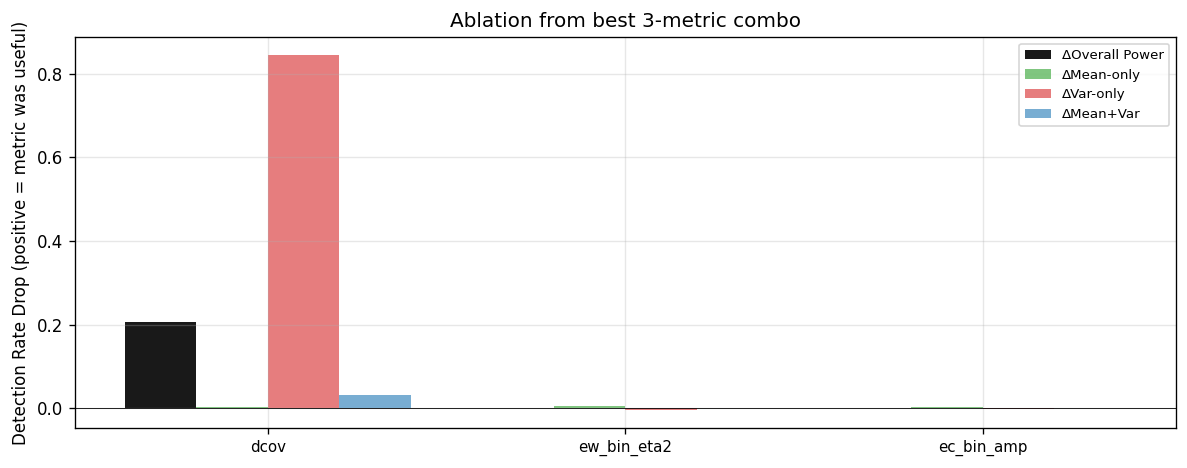


Ablation from best 4-metric combo: ['dcov', 'ew_bin_eta2', '|std_pf_early', 'ec_bin_amp']
Baseline Overall Power: 98.4%  (MO=97.2%  VO=97.5%  MV=100.0%)
  Remove dcov                      → ΔPower=+20.8%  (ΔMO=+0.5%  ΔVO=+84.4%  ΔMV=+3.2%)  FPR=5.0%
  Remove ew_bin_eta2               → ΔPower=+0.1%  (ΔMO=+0.5%  ΔVO=-0.2%  ΔMV=+0.0%)  FPR=5.0%
  Remove |std_pf_early             → ΔPower=+0.0%  (ΔMO=+0.2%  ΔVO=-0.3%  ΔMV=+0.0%)  FPR=5.0%
  Remove ec_bin_amp                → ΔPower=+0.0%  (ΔMO=+0.1%  ΔVO=-0.1%  ΔMV=+0.0%)  FPR=5.0%


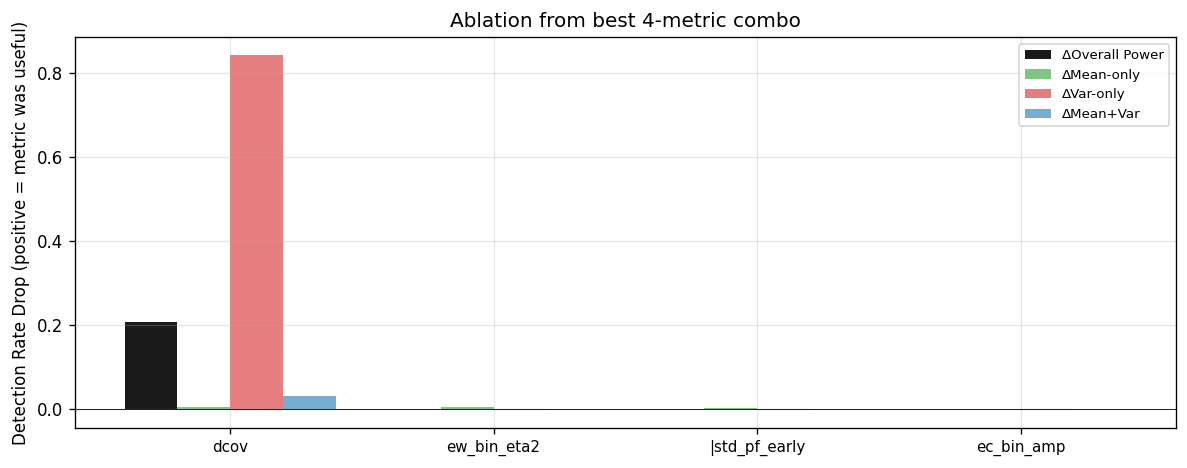


Ablation from best 5-metric combo: ['dcov', 'ew_bin_eta2', 'mic', '|std_pf_early', 'ec_bin_amp']
Baseline Overall Power: 98.4%  (MO=97.2%  VO=97.8%  MV=99.9%)
  Remove dcov                      → ΔPower=+3.7%  (ΔMO=+0.6%  ΔVO=+10.4%  ΔMV=+2.9%)  FPR=5.0%
  Remove ew_bin_eta2               → ΔPower=+0.2%  (ΔMO=+0.6%  ΔVO=-0.1%  ΔMV=+0.0%)  FPR=5.0%
  Remove mic                       → ΔPower=+0.0%  (ΔMO=-0.0%  ΔVO=+0.3%  ΔMV=-0.0%)  FPR=5.0%
  Remove |std_pf_early             → ΔPower=+0.1%  (ΔMO=+0.3%  ΔVO=-0.1%  ΔMV=-0.0%)  FPR=5.0%
  Remove ec_bin_amp                → ΔPower=+0.1%  (ΔMO=+0.2%  ΔVO=+0.0%  ΔMV=+0.0%)  FPR=5.0%


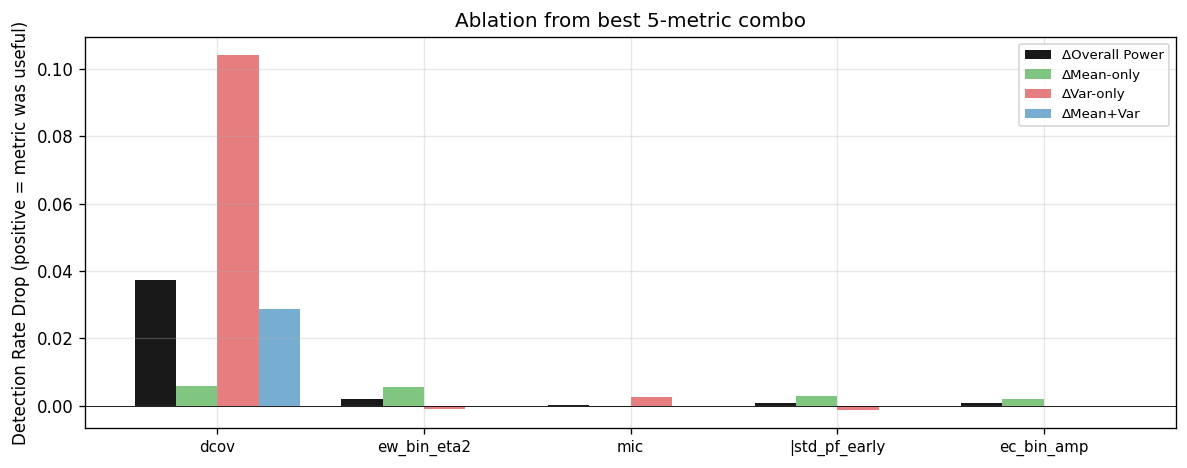

In [52]:
# Ablation from best combos (3, 4, 5 metrics)
for base_k in [3, 4, 5]:
    if base_k not in best_per_size:
        continue
    base = best_per_size[base_k]
    base_metrics = list(base['metrics'])
    base_names = [METRIC_DISPLAY[m] for m in base_metrics]

    print(f'\n{"="*60}')
    print(f'Ablation from best {base_k}-metric combo: {base_names}')
    print(f'Baseline Overall Power: {base["overall_power"]:.1%}  '
          f'(MO={base["rate_mean_only"]:.1%}  VO={base["rate_variance_only"]:.1%}  '
          f'MV={base["rate_mean+variance"]:.1%})')
    print(f'{"="*60}')

    ablation_rows = []
    for remove in base_metrics:
        remaining = [m for m in base_metrics if m != remove]
        result = evaluate_combo(df, df['category'], remaining)
        drop_power = base['overall_power'] - result['overall_power']
        drop_mo = base['rate_mean_only'] - result['rate_mean_only']
        drop_vo = base['rate_variance_only'] - result['rate_variance_only']
        drop_mv = base['rate_mean+variance'] - result['rate_mean+variance']

        ablation_rows.append({
            'removed': METRIC_DISPLAY[remove],
            'group': METRIC_GROUPS[remove],
            'drop_power': drop_power,
            'drop_MO': drop_mo,
            'drop_VO': drop_vo,
            'drop_MV': drop_mv,
            'remaining_FPR': result['rate_true_null']
        })
        print(f'  Remove {METRIC_DISPLAY[remove]:25s} → '
              f'ΔPower={drop_power:+.1%}  '
              f'(ΔMO={drop_mo:+.1%}  ΔVO={drop_vo:+.1%}  ΔMV={drop_mv:+.1%})  '
              f'FPR={result["rate_true_null"]:.1%}')

    abl_df = pd.DataFrame(ablation_rows)
    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(abl_df))
    w = 0.2
    ax.bar([i - 1.5*w for i in x], abl_df['drop_power'], w, label='ΔOverall Power', color='black', alpha=0.9)
    ax.bar([i - 0.5*w for i in x], abl_df['drop_MO'], w, label='ΔMean-only', color='#2ca02c', alpha=0.6)
    ax.bar([i + 0.5*w for i in x], abl_df['drop_VO'], w, label='ΔVar-only', color='#d62728', alpha=0.6)
    ax.bar([i + 1.5*w for i in x], abl_df['drop_MV'], w, label='ΔMean+Var', color='#1f77b4', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(abl_df['removed'], fontsize=9)
    ax.set_ylabel('Detection Rate Drop (positive = metric was useful)')
    ax.set_title(f'Ablation from best {base_k}-metric combo')
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', lw=0.5)
    plt.tight_layout()
    plt.show()

## 8. Best Combination Deep Dive

For the recommended combination, show detection by family and SNR.


Best 3-metric: ['dcov', 'ew_bin_eta2', 'ec_bin_amp']


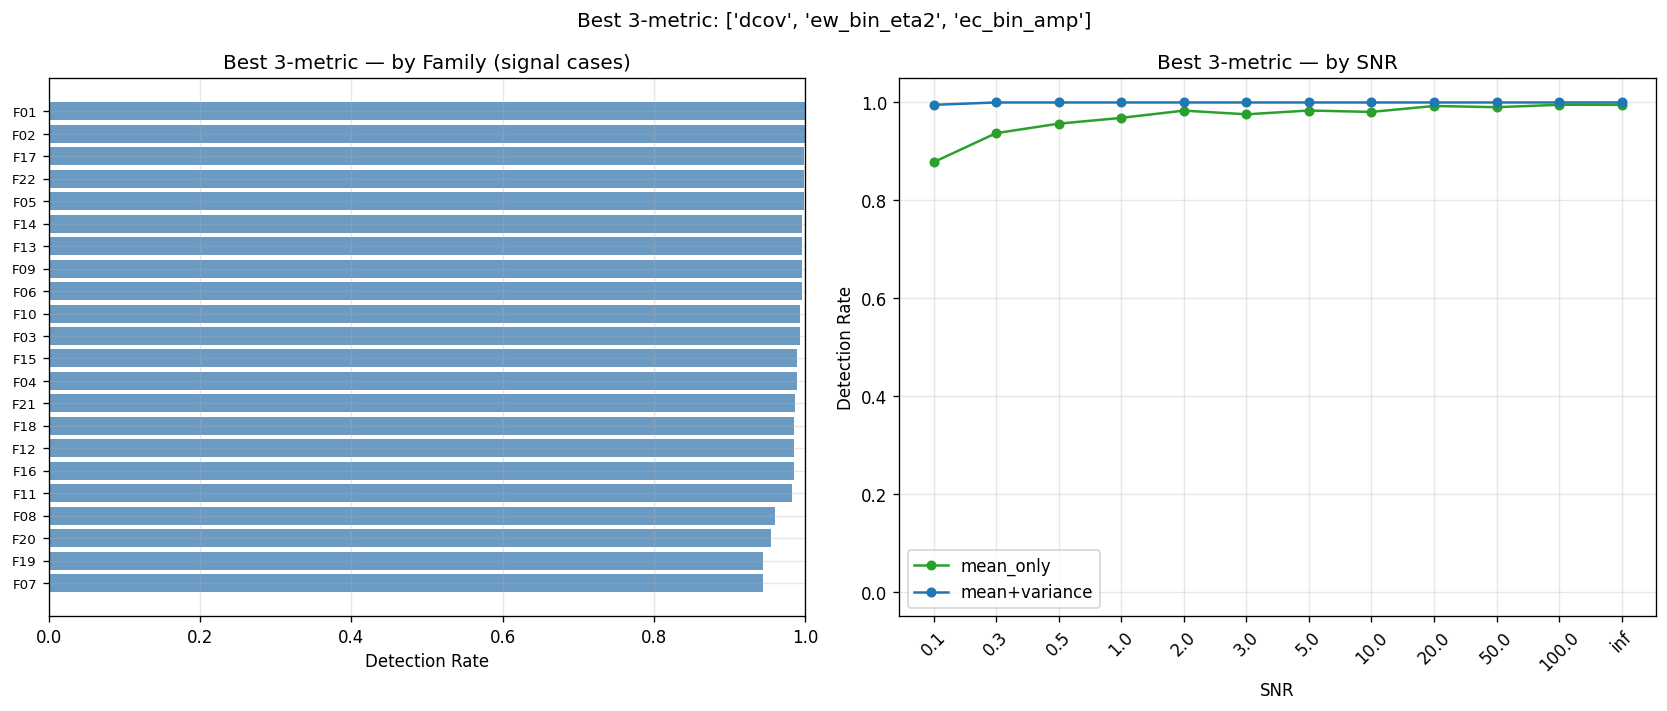


Driving metric (signal detected cases):
  ew_bin_eta2                      8,044  (81.7%)
  dcov                             1,756  (17.8%)
  ec_bin_amp                          48  (0.5%)

Driving metric (variance-only cases):
  dcov                             2,955  (99.3%)
  ew_bin_eta2                         16  (0.5%)
  ec_bin_amp                           5  (0.2%)

Best 5-metric: ['dcov', 'ew_bin_eta2', 'mic', '|std_pf_early', 'ec_bin_amp']


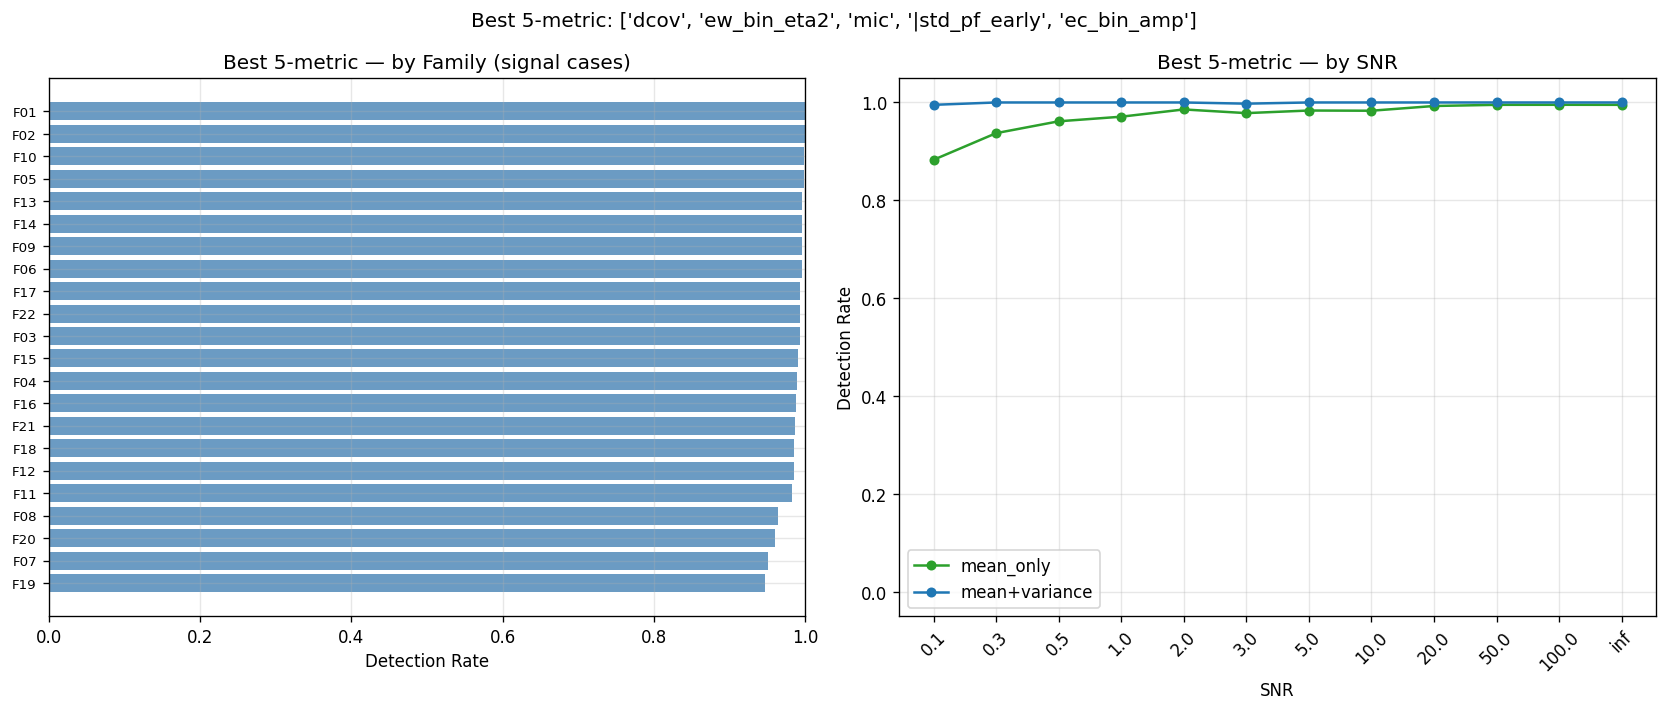


Driving metric (signal detected cases):
  ew_bin_eta2                      8,016  (81.3%)
  dcov                             1,722  (17.5%)
  |std_pf_early                       48  (0.5%)
  ec_bin_amp                          42  (0.4%)
  mic                                 29  (0.3%)

Driving metric (variance-only cases):
  dcov                             1,870  (62.8%)
  mic                              1,088  (36.6%)
  ew_bin_eta2                         14  (0.5%)
  ec_bin_amp                           4  (0.1%)


In [53]:
# Use the best 3-metric and 5-metric combos
for label, k in [('Best 3-metric', 3), ('Best 5-metric', 5)]:
    if k not in best_per_size:
        continue
    r = best_per_size[k]
    metrics = list(r['metrics'])
    names = [METRIC_DISPLAY[m] for m in metrics]
    
    T = df[metrics].max(axis=1)
    threshold = r['threshold']
    detected = T > threshold
    
    print(f'\n{"="*60}')
    print(f'{label}: {names}')
    print(f'{"="*60}')
    
    # Detection by family (mean_only + mean+variance)
    signal = df[df['category'].isin(['mean_only', 'mean+variance'])].copy()
    signal['detected'] = detected[signal.index]
    fam_rates = signal.groupby('family_id')['detected'].mean().sort_values(ascending=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # By family
    ax1.barh(range(len(fam_rates)), fam_rates.values, color='steelblue', alpha=0.8)
    ax1.set_yticks(range(len(fam_rates)))
    ax1.set_yticklabels(fam_rates.index, fontsize=8)
    ax1.set_xlabel('Detection Rate')
    ax1.set_title(f'{label} — by Family (signal cases)')
    ax1.set_xlim(0, 1)
    
    # By SNR
    for cat, color, ls in [('mean_only', '#2ca02c', '-'),
                            ('mean+variance', '#1f77b4', '--')]:
        sub = df[df['category'] == cat].copy()
        sub['detected'] = detected[sub.index]
        snr_rates = sub.groupby('snr')['detected'].mean()
        ax2.plot(range(len(snr_rates)), snr_rates.values, 'o-',
                 label=cat, color=color, markersize=5)
    
    snr_labels = [str(s) for s in sorted(df['snr'].unique())]
    ax2.set_xticks(range(len(snr_labels)))
    ax2.set_xticklabels(snr_labels, rotation=45)
    ax2.set_xlabel('SNR')
    ax2.set_ylabel('Detection Rate')
    ax2.set_title(f'{label} — by SNR')
    ax2.legend()
    ax2.set_ylim(-0.05, 1.05)
    
    fig.suptitle(f'{label}: {names}', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Driving metric analysis
    driving = df[metrics].idxmax(axis=1)
    driving_signal = driving[df['category'].isin(['mean_only', 'mean+variance']) & detected]
    driving_vo = driving[df['category'] == 'variance_only']
    
    print(f'\nDriving metric (signal detected cases):')
    counts = driving_signal.value_counts()
    for m, n in counts.items():
        print(f'  {METRIC_DISPLAY[m]:30s}  {n:>6,}  ({n/len(driving_signal):.1%})')
    
    print(f'\nDriving metric (variance-only cases):')
    counts = driving_vo.value_counts()
    for m, n in counts.items():
        print(f'  {METRIC_DISPLAY[m]:30s}  {n:>6,}  ({n/len(driving_vo):.1%})')

## 9. Conclusion

Recommended metric combination for binary detection: **no relationship vs has relationship**.

In [54]:
print('=' * 70)
print('Metric Selection: detecting "no relationship" vs "has relationship"')
print('=' * 70)
print()
print(f'{"k":>2s}  {"Overall Power":>14s}  {"FPR":>5s}  │ {"MO":>5s}  {"VO":>5s}  {"MV":>5s}  │ Metrics')
print('─' * 80)
for k in sorted(best_per_size.keys()):
    r = best_per_size[k]
    names = ', '.join(METRIC_DISPLAY[m] for m in r['metrics'])
    print(f'{k:>2d}  {r["overall_power"]:>13.1%}  {r["rate_true_null"]:>5.1%}  │ '
          f'{r["rate_mean_only"]:>5.1%}  {r["rate_variance_only"]:>5.1%}  {r["rate_mean+variance"]:>5.1%}  │ {names}')

print()
print('Key finding:')
print(f'  → dcov alone achieves {best_per_size[1]["overall_power"]:.1%} overall power at FPR={best_per_size[1]["rate_true_null"]:.1%}')
print(f'  → Adding more metrics gives marginal improvement (+{best_per_size[6]["overall_power"] - best_per_size[1]["overall_power"]:.1%} with 5 extra metrics)')
print(f'  → The joint max-Z test is dominated by dcov/dcor (distance covariance)')
print()
print('Recommendation: Use dcov (or dcov + 1-2 complementary metrics for robustness)')

Metric Selection: detecting "no relationship" vs "has relationship"

 k   Overall Power    FPR  │    MO     VO     MV  │ Metrics
────────────────────────────────────────────────────────────────────────────────
 1          98.1%   5.0%  │ 95.8%  98.7%  100.0%  │ dcov
 2          98.3%   5.0%  │ 96.8%  97.9%  100.0%  │ dcov, ew_bin_eta2
 3          98.3%   5.0%  │ 97.0%  97.8%  100.0%  │ dcov, ew_bin_eta2, ec_bin_amp
 4          98.4%   5.0%  │ 97.2%  97.5%  100.0%  │ dcov, ew_bin_eta2, |std_pf_early, ec_bin_amp
 5          98.4%   5.0%  │ 97.2%  97.8%  99.9%  │ dcov, ew_bin_eta2, mic, |std_pf_early, ec_bin_amp
 6          98.4%   5.0%  │ 97.2%  97.8%  99.9%  │ dcov, |spearman_rho, ew_bin_eta2, mic, |std_pf_early, ec_bin_amp

Key finding:
  → dcov alone achieves 98.1% overall power at FPR=5.0%
  → Adding more metrics gives marginal improvement (+0.3% with 5 extra metrics)
  → The joint max-Z test is dominated by dcov/dcor (distance covariance)

Recommendation: Use dcov (or dcov + 1-2 com